In [ ]:
#DONE: Actually optimize the random equations
# Got some random three equations
#DONE: Reweight the points by det g of the fubini-Study metric (Double check which metric we should use)

#TODO install jax gpu
#TODO After each training step, print out the point clouds and outputting the equations to see how the solutions evolve
#TODO Optimize on RP3, set a proper max step
#TODO Run some clustering algorithm to force clustering?
#TODO Since real submanifold is 3D, we can plot that directly? Check the dimension of the 
# underlying manifold of the point cloud. 
#DONE Print out all losses, see if there is any overfit at k = 500 (A little but not too much)
#Potential checks one can do:
#Persistant homology

# Manifold learning, encoder, decoder, set latent dim = 3
# The jacobian in the transverse loss might be large even on RP^3

# avoid the obivous |z0|^2 = 1

In [1]:
from find_smooth_submanifold import *
import jax
import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np

Note 1: Here we will just pick one patch. For a set of three equations, it is common that the error is smaller on patch but large on another patch. But the key is that since we are all using homogeneous coordinates, we can always find an equivalent set of equations so that it reprents the same submainfold, but error is small on the patch we choose.

Note 2: Since the points on the quintic is sampled with respected to the Fubini-Study metric, certain regions have more points in it, making it easier for find points with small loss in that region. It is possible that the search will be skewed towards those regions. (RP^3 is slightly more concentrated but does not have the largest volume.) This issue is not very easy to deal with, so far we just ignore it and hope it won't affect the result too much. (in a sense that even though it is easier to certain regions, it is still likely to find solutions in other parts, unless the points are supper sparse.)

In [3]:
with open('/home/spencer/Documents/SLagSearch_old/5mil_patch0.pkl', 'rb') as f:
    pts_5mil_patch0 = pickle.load(f)

In [4]:
with open('/home/spencer/Documents/SLagSearch/5mil_patch0_1234.pkl', 'rb') as f:
    pts_5mil_patch0_1234 = pickle.load(f)

In [2]:
with open('/home/spencer/Documents/SLagSearch/25mil_patch0.pkl', 'rb') as f:
    pts_25mil_patch0 = pickle.load(f)

In [6]:
pts_5mil_patch0 = jnp.asarray(pts_5mil_patch0)
basis = generate_basis(pts_5mil_patch0)

In [7]:
pts_5mil_patch0_1234 = jnp.asarray(pts_5mil_patch0_1234)
basis_2 = generate_basis(pts_5mil_patch0_1234)

In [3]:
pts_25mil_patch0 = jnp.asarray(pts_25mil_patch0)
basis_25mil = generate_basis(pts_25mil_patch0)

In [4]:
pts_25mil_patch0.shape

(5000457, 5)

In [9]:
seed = 42

# Initialize coefficients with focus on imaginary cross terms
key = jax.random.PRNGKey(seed)
    
# Start with random initialization
coeffs_random = jax.random.uniform(key, (5, 3, 25), minval=-1, maxval=1)

In [10]:
coeffs_random

Array([[[-0.02258086,  0.35959435,  0.23254299,  0.12203217,
         -0.09871078,  0.17173171, -0.85038114,  0.55026674,
          0.39791846,  0.63726735, -0.2993896 ,  0.74564004,
          0.8517628 ,  0.72026134, -0.04489183,  0.6369636 ,
          0.422709  ,  0.17339444, -0.85252523,  0.55524445,
         -0.19086885, -0.76175356, -0.9474888 ,  0.2783575 ,
         -0.19053769],
        [ 0.77568245, -0.83705115, -0.40719032,  0.21335936,
          0.87646985,  0.5120158 , -0.08273292, -0.38454843,
          0.5017104 ,  0.0882647 , -0.2719717 ,  0.35082078,
          0.180228  , -0.42250347, -0.62276983, -0.16906357,
          0.2419262 , -0.14851117,  0.07460117,  0.29150724,
         -0.7095854 ,  0.34488726,  0.7740259 ,  0.33562732,
         -0.5184231 ],
        [ 0.14001465, -0.15750551, -0.17265391,  0.8012955 ,
          0.29260087, -0.14133763, -0.18950772, -0.3180585 ,
          0.28646874,  0.76512575, -0.7009592 , -0.57298326,
          0.7101989 , -0.28275895, -0.0

In [11]:
coeffs_RP3 = jnp.zeros((3, 25)).at[[0, 1, 2], [0, 1, 2]].set(1)
coeffs_T3 = jnp.zeros((3, 25)).at[[0, 1, 2], [10, 15, 19]].set(1).at[[0, 1, 2],[15, 19, 22]].set(-1)

In [12]:
coeffs_T3

Array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0., -1.,  0.,  0.]],      dtype=float32)

In [13]:
coeffs_simple = jnp.zeros((3, 25)).at[[0, 0, 0, 1, 1, 2], [3, 5, 6, 11, 12, 13]].set(1)
coeffs_simple2 = jnp.zeros((3, 25)).at[[0, 0, 0, 1, 1, 2, 2], [0, 1, 5, 2, 4, 21, 23]].set(1)
coeffs_simple3 = jnp.zeros((3, 25)).at[[0, 1, 2], [0, 1, 13]].set(1)

In [14]:
labels = np.array(get_basis_labels())

In [15]:
print(labels[[3, 5, 6, 11, 12, 13]])
print(labels[[0, 1, 5, 2, 4, 21, 23]])
print(labels[[0,1,13]])

['Im(z0*z4bar)' 'Im(z1*z3bar)' 'Im(z1*z4bar)' 'Re(z0*z1bar)'
 'Re(z0*z2bar)' 'Re(z0*z3bar)']
['Im(z0*z1bar)' 'Im(z0*z2bar)' 'Im(z1*z3bar)' 'Im(z0*z3bar)'
 'Im(z1*z2bar)' 'Re(z2*z4bar)' 'Re(z3*z4bar)']
['Im(z0*z1bar)' 'Im(z0*z2bar)' 'Re(z0*z3bar)']


In [16]:
labels

array(['Im(z0*z1bar)', 'Im(z0*z2bar)', 'Im(z0*z3bar)', 'Im(z0*z4bar)',
       'Im(z1*z2bar)', 'Im(z1*z3bar)', 'Im(z1*z4bar)', 'Im(z2*z3bar)',
       'Im(z2*z4bar)', 'Im(z3*z4bar)', 'Re(z0*z0bar)', 'Re(z0*z1bar)',
       'Re(z0*z2bar)', 'Re(z0*z3bar)', 'Re(z0*z4bar)', 'Re(z1*z1bar)',
       'Re(z1*z2bar)', 'Re(z1*z3bar)', 'Re(z1*z4bar)', 'Re(z2*z2bar)',
       'Re(z2*z3bar)', 'Re(z2*z4bar)', 'Re(z3*z3bar)', 'Re(z3*z4bar)',
       'Re(z4*z4bar)'], dtype='<U12')

In [17]:
print(labels[[10, 15, 19, 22]])

['Re(z0*z0bar)' 'Re(z1*z1bar)' 'Re(z2*z2bar)' 'Re(z3*z3bar)']


In [18]:
coeffs_ce = jnp.zeros((3, 25)).at[[0, 1, 2], [19, 22, 24]].set(1)
coeffs_ce = normalize_coeffs(coeffs_ce)

In [19]:
coeffs_RP3 = normalize_coeffs(coeffs_RP3)
coeffs_T3 = normalize_coeffs(coeffs_T3)
coeffs_simple = normalize_coeffs(coeffs_simple)
coeffs_simple2 = normalize_coeffs(coeffs_simple2)
coeffs_simple3 = normalize_coeffs(coeffs_simple3)
for i in range(5):
    coeffs_random = coeffs_random.at[i].set(normalize_coeffs(coeffs_random[i]))

In [15]:
loss_RP3_list = []
loss_T3_list = []
loss_random1_list = []
loss_random2_list = []
loss_random3_list = []
loss_random4_list = []
loss_random5_list = []
loss_simple1_list = []
loss_simple2_list = []
loss_simple3_list = []

for k in range(1, 1000, 50):
    loss_RP3_list.append(loss_function(coeffs_RP3, basis, k=k, lambda_reg=0))
    loss_T3_list.append(loss_function(coeffs_T3, basis, k=k, lambda_reg=0))
    loss_random1_list.append(loss_function(coeffs_random[0], basis, k=k, lambda_reg=0))
    loss_random2_list.append(loss_function(coeffs_random[1], basis, k=k, lambda_reg=0))
    loss_random3_list.append(loss_function(coeffs_random[2], basis, k=k, lambda_reg=0))
    loss_random4_list.append(loss_function(coeffs_random[3], basis, k=k, lambda_reg=0))
    loss_random5_list.append(loss_function(coeffs_random[4], basis, k=k, lambda_reg=0))
    loss_simple1_list.append(loss_function(coeffs_simple, basis, k=k, lambda_reg=0))
    loss_simple2_list.append(loss_function(coeffs_simple2, basis, k=k, lambda_reg=0))
    loss_simple3_list.append(loss_function(coeffs_simple3, basis, k=k, lambda_reg=0))

KeyboardInterrupt: 

In [ ]:
# Create figure and axis
plot_random = False
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(1, 1000, 50)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3_list, label='RP3', linewidth=2)
plt.plot(x, loss_T3_list, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple1_list, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2_list, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3_list, label='Simple3', linewidth=2)

# Plot random losses
if plot_random:
    plt.plot(x, loss_random1_list, label='Random1', linewidth=2)
    plt.plot(x, loss_random2_list, label='Random2', linewidth=2)
    plt.plot(x, loss_random3_list, label='Random3', linewidth=2)
    plt.plot(x, loss_random4_list, label='Random4', linewidth=2)
    plt.plot(x, loss_random5_list, label='Random5', linewidth=2)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss')
#plt.yscale('log')
plt.title('Loss vs the number of points in the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('loss_vs_k_1mil_without_random.png')
plt.show()

In [ ]:
# Create figure and axis
plot_random = True
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(1, 1000, 50)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3_list, label='RP3', linewidth=2)
plt.plot(x, loss_T3_list, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple1_list, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2_list, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3_list, label='Simple3', linewidth=2)

# Plot random losses
if plot_random:
    plt.plot(x, loss_random1_list, label='Random1', linewidth=2)
    plt.plot(x, loss_random2_list, label='Random2', linewidth=2)
    plt.plot(x, loss_random3_list, label='Random3', linewidth=2)
    plt.plot(x, loss_random4_list, label='Random4', linewidth=2)
    plt.plot(x, loss_random5_list, label='Random5', linewidth=2)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss')
#plt.yscale('log')
plt.title('Loss vs the number of points in the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('loss_vs_k_1mil_with_random.png')
plt.show()

In [ ]:
k = 1000
loss_RP3 = loss_function_array(coeffs_RP3, basis, k=k)
loss_T3 = loss_function_array(coeffs_T3, basis, k=k)
loss_random = []
for i in range(5):
    loss_rand = loss_function_array(coeffs_random[i], basis, k=k)
    loss_random.append(loss_rand)
    
loss_simple = loss_function_array(coeffs_simple, basis, k=k)
loss_simple2 = loss_function_array(coeffs_simple2, basis, k=k)
loss_simple3 = loss_function_array(coeffs_simple3, basis, k=k)

In [ ]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_without_random.png')
plt.show()

In [ ]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Plot random losses
for i in range(5):
    plt.plot(x, loss_random[i], label=f'Random {i+1}', alpha=0.7)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(find_satisfying_points, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_with_random.png')
plt.show()

In [25]:
pt_x[~loss_mask].shape

(500,)

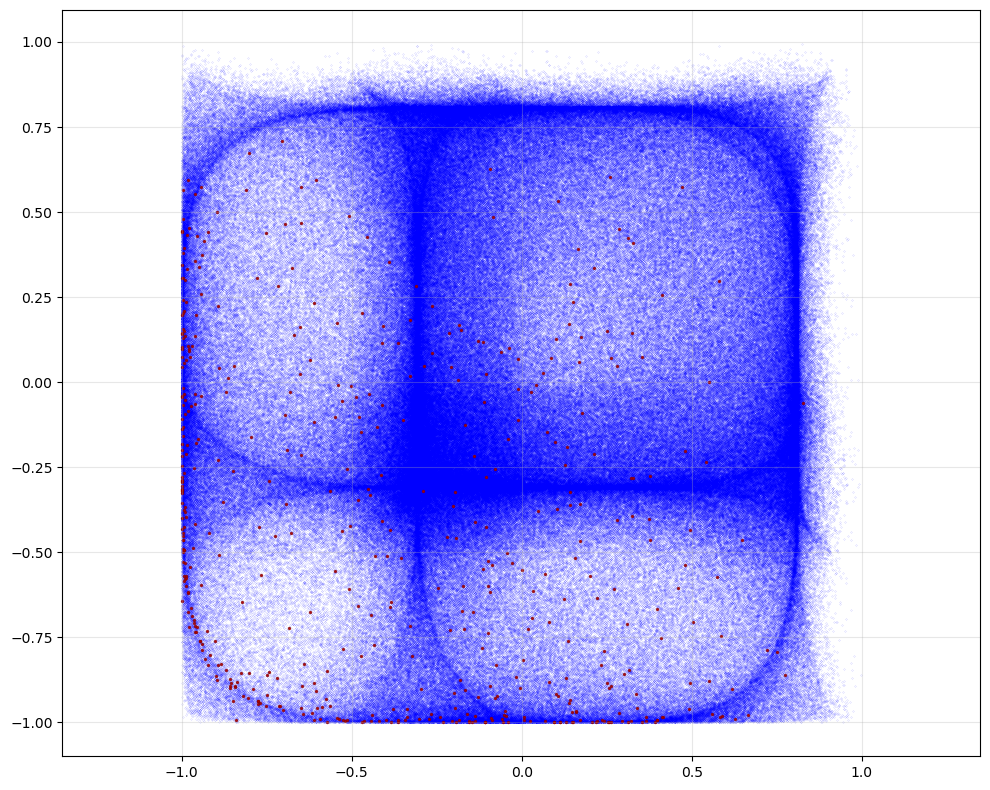

In [245]:
# Extract z0 (first column)
#z0 = pts_5mil_patch0[:, 2]
pt_x = np.real(pts_5mil_patch0[:, 1])
pt_y = np.real(pts_5mil_patch0[:, 2])

loss_idx = find_satisfying_points(coeffs_RP3, basis, k=500)
# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot points that don't satisfy the condition in blue
plt.scatter(pt_x, 
            pt_y, 
            c='blue', 
            alpha=0.6, 
            label='Normal points',
            s=.01)

# Plot points that satisfy the condition in red
plt.scatter(pt_x[loss_idx], 
            pt_y[loss_idx], 
            c='red', 
            alpha=0.8, 
            label='Equal modulus points',
            s=2,
            edgecolor='darkred',
            linewidth=1)

#plt.xlabel('Real(z₀)', fontsize=12)
#plt.ylabel('Imag(z₀)', fontsize=12)
#plt.title('Scatter Plot of Complex Points z₀\n(Red: |z₀|² = |z₁|² = |z₂|² = |z₃|²)', fontsize=14)
plt.grid(True, alpha=0.3)
#plt.legend()
plt.axis('equal')  # Equal aspect ratio


plt.tight_layout()
plt.show()

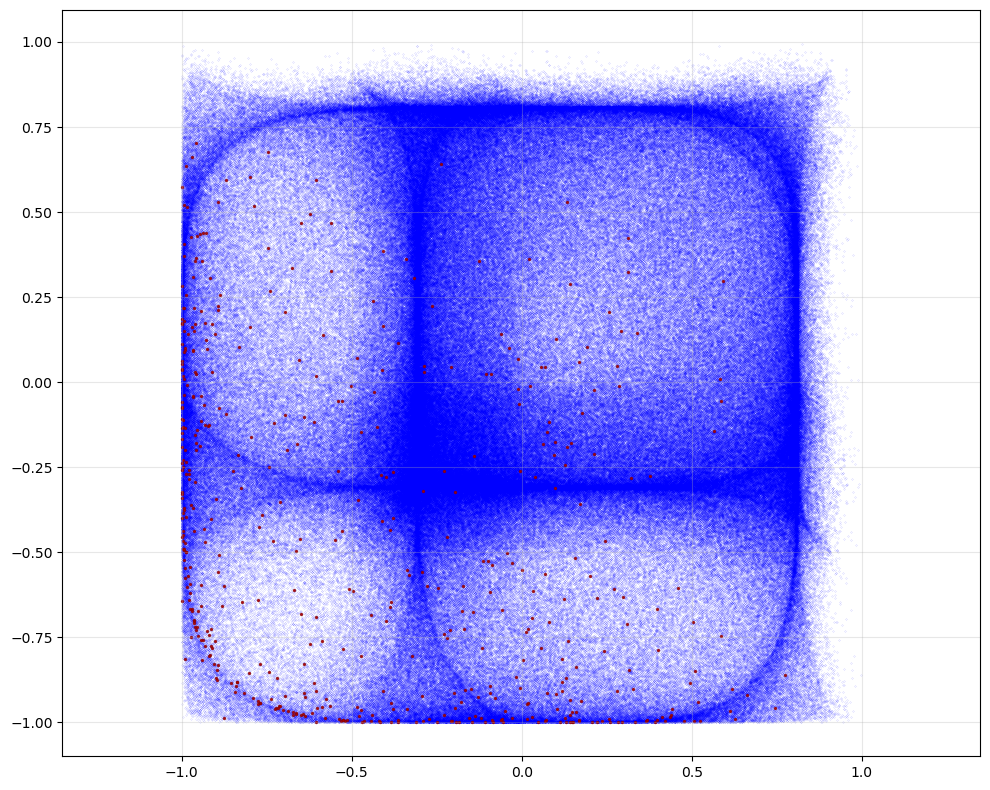

In [244]:
# Extract z0 (first column)
#z0 = pts_5mil_patch0[:, 2]
pt_x = np.real(pts_5mil_patch0[:, 1])
pt_y = np.real(pts_5mil_patch0[:, 2])

loss_idx = find_satisfying_points(coeffs_from_rp3, basis, k=500)
# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot points that don't satisfy the condition in blue
plt.scatter(pt_x, 
            pt_y, 
            c='blue', 
            alpha=0.6, 
            label='Normal points',
            s=.01)

# Plot points that satisfy the condition in red
plt.scatter(pt_x[loss_idx], 
            pt_y[loss_idx], 
            c='red', 
            alpha=0.8, 
            label='Equal modulus points',
            s=2,
            edgecolor='darkred',
            linewidth=1)

#plt.xlabel('Real(z₀)', fontsize=12)
#plt.ylabel('Imag(z₀)', fontsize=12)
#plt.title('Scatter Plot of Complex Points z₀\n(Red: |z₀|² = |z₁|² = |z₂|² = |z₃|²)', fontsize=14)
plt.grid(True, alpha=0.3)
#plt.legend()
plt.axis('equal')  # Equal aspect ratio


plt.tight_layout()
plt.show()

In [169]:
pts_5mil_patch0[loss_idx]

Array([[ 1.        -0.j        , -0.6437878 +0.01698887j,
        -0.9749333 -0.00320762j, -0.39201036-0.00227254j,
        -0.19471683+0.02692284j],
       [ 1.        +0.j        , -0.7732468 +0.02053566j,
        -0.42631274+0.01767829j, -0.9575488 -0.01404944j,
        -0.5186866 +0.34462225j],
       [ 1.        -0.j        ,  0.03384839+0.02182872j,
        -0.6145244 +0.03390741j, -0.9824441 -0.00516195j,
        -0.04827976-0.11614624j],
       ...,
       [ 1.        +0.j        , -0.9910571 -0.01737708j,
        -0.09370031-0.02387183j, -0.4895482 +0.02824438j,
        -0.32794288-0.503316j  ],
       [ 1.        -0.j        , -0.96466154+0.00403875j,
        -0.7069694 +0.00561877j, -0.30828562+0.03664115j,
        -0.45321384-0.19870947j],
       [ 1.        +0.j        , -0.99399674+0.00185336j,
        -0.4935661 -0.03320996j, -0.27928138+0.01951347j,
         0.15849324+0.07699744j]], dtype=complex64)

In [11]:
# Main execution
if __name__ == "__main__":
 
    # points = jnp.array(np.load("fermat_quintic_points.npy"))

    
    # Optimize equations
    print("\nOptimizing equations...")
    coeffs, losses = optimize_equations(
        pts_5mil_patch0, 
        init_coeffs=None,
        learning_rate=0.01, 
        num_steps=3000,
        num_min_set=500,
        lambda_reg=0.1
    )
    
    # Analyze solution
   # analyze_solution(coeffs, points)
    
    # Save results
    #np.save("optimized_coefficients.npy", np.array(coeffs))
    #print("\nCoefficients saved to 'optimized_coefficients.npy'")


Optimizing equations...
Step 0, Loss: 0.789445
Step 10, Loss: 0.354575
Step 20, Loss: 0.259216
Step 30, Loss: 0.189749
Step 40, Loss: 0.145476
Step 50, Loss: 0.125534
Step 60, Loss: 0.116684
Step 70, Loss: 0.109738
Step 80, Loss: 0.107313
Step 90, Loss: 0.097546
Step 100, Loss: 0.103099
Step 110, Loss: 0.092896
Step 120, Loss: 0.089097
Step 130, Loss: 0.088657
Step 140, Loss: 0.090448
Step 150, Loss: 0.091509
Step 160, Loss: 0.085150
Step 170, Loss: 0.083741
Step 180, Loss: 0.089637
Step 190, Loss: 0.089110
Step 200, Loss: 0.083234
Step 210, Loss: 0.086429
Step 220, Loss: 0.088755
Step 230, Loss: 0.079913
Step 240, Loss: 0.085922
Step 250, Loss: 0.088851
Step 260, Loss: 0.083135
Step 270, Loss: 0.082393
Step 280, Loss: 0.085002
Step 290, Loss: 0.083401
Step 300, Loss: 0.086833
Step 310, Loss: 0.084627
Step 320, Loss: 0.084979
Step 330, Loss: 0.081495
Step 340, Loss: 0.081011
Step 350, Loss: 0.081043
Step 360, Loss: 0.077540
Step 370, Loss: 0.077071
Step 380, Loss: 0.076301
Step 390, L

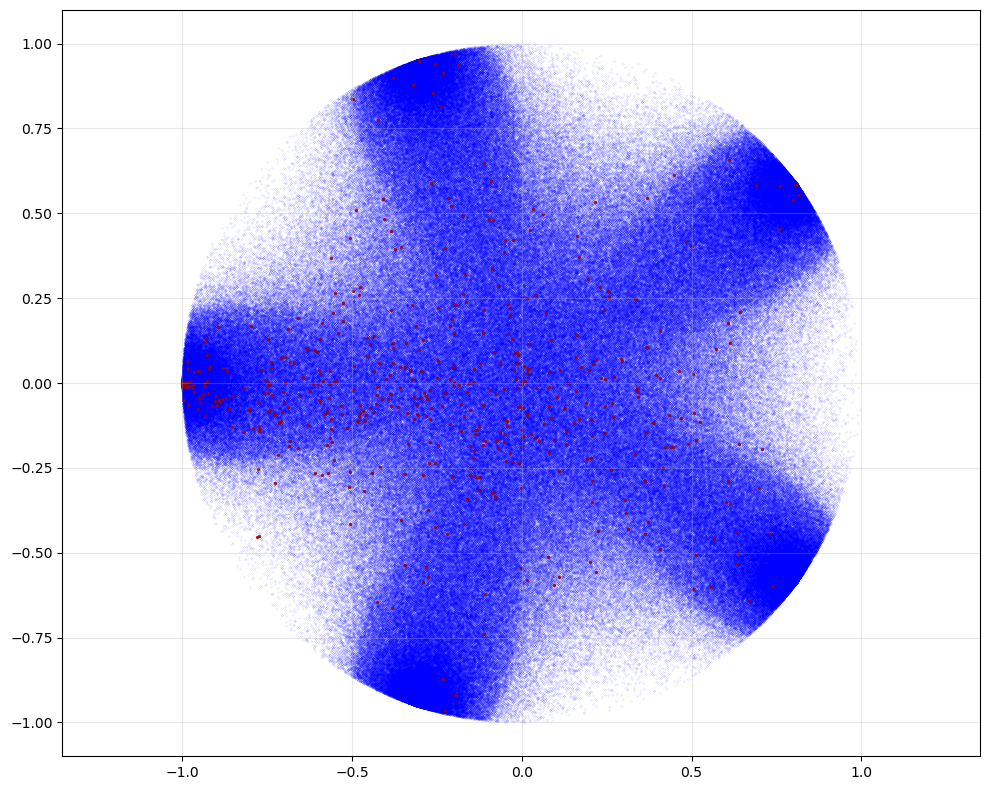

In [13]:
# Extract z0 (first column)
#z0 = pts_5mil_patch0[:, 2]
pt_x = np.real(pts_5mil_patch0[:, 1])
pt_y = np.imag(pts_5mil_patch0[:, 1])

loss_idx = find_satisfying_points(coeffs, basis, k=500)
# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot points that don't satisfy the condition in blue
plt.scatter(pt_x, 
            pt_y, 
            c='blue', 
            alpha=0.6, 
            label='Normal points',
            s=.01)

# Plot points that satisfy the condition in red
plt.scatter(pt_x[loss_idx], 
            pt_y[loss_idx], 
            c='red', 
            alpha=0.8, 
            label='Equal modulus points',
            s=2,
            edgecolor='darkred',
            linewidth=1)

#plt.xlabel('Real(z₀)', fontsize=12)
#plt.ylabel('Imag(z₀)', fontsize=12)
#plt.title('Scatter Plot of Complex Points z₀\n(Red: |z₀|² = |z₁|² = |z₂|² = |z₃|²)', fontsize=14)
plt.grid(True, alpha=0.3)
#plt.legend()
plt.axis('equal')  # Equal aspect ratio


plt.tight_layout()
plt.show()

In [14]:
loss_function(coeffs_RP3, basis, k=500, lambda_reg=0)

Array(0.50557095, dtype=float32)

In [128]:
loss_function(coeffs_RP3, basis_2, k=500, lambda_reg=0)

Array(0.53051823, dtype=float32)

In [34]:
intersection = pts_5mil_patch0[loss_idx]

In [129]:
loss_function(coeffs, basis, k=500, lambda_reg=1)

Array(0.07799078, dtype=float32)

In [130]:
loss_function(coeffs, basis_2, k=500, lambda_reg=1)

Array(0.12396004, dtype=float32)

In [18]:
loss_function_array(coeffs, basis, k=500)

Array([2.92171217e-06, 3.06210472e-06, 3.56342412e-06, 3.94316658e-06,
       4.60289266e-06, 5.49719653e-06, 8.09828816e-06, 9.23279822e-06,
       9.50132198e-06, 9.89924320e-06, 1.04866540e-05, 1.50235264e-05,
       1.56517635e-05, 1.69707091e-05, 1.74846700e-05, 1.93823125e-05,
       1.94668246e-05, 1.96530054e-05, 1.98844155e-05, 1.99077876e-05,
       2.01637395e-05, 2.13383701e-05, 2.16893895e-05, 2.29843426e-05,
       2.35865446e-05, 2.49648492e-05, 2.49810546e-05, 2.69654320e-05,
       2.70482014e-05, 2.72398538e-05, 2.80510249e-05, 2.89908385e-05,
       2.95909813e-05, 3.16724436e-05, 3.19805804e-05, 3.20469917e-05,
       3.22335363e-05, 3.29046597e-05, 3.32286654e-05, 3.45521839e-05,
       3.56233832e-05, 3.58431935e-05, 3.61013736e-05, 3.73570292e-05,
       3.78902187e-05, 3.81980426e-05, 3.86687097e-05, 3.92365655e-05,
       3.93947812e-05, 3.95387433e-05, 4.02536243e-05, 4.09763925e-05,
       4.13390153e-05, 4.16365983e-05, 4.19796488e-05, 4.26321967e-05,
      

In [23]:
from collections import defaultdict

def combine_to_complex_equations(labels, coeffs):
    """
    Convert equations from Re/Im basis to zi*zjbar basis using:
    Im(zi*zjbar) = (zi*zjbar - zj*zibar)/(2i)
    Re(zi*zjbar) = (zi*zjbar + zj*zibar)/2
    
    Parameters:
    labels: array of strings like 'Im(z0*z1bar)', 'Re(z0*z1bar)'
    coeffs: 3x25 array of coefficients
    
    Returns:
    List of 3 strings representing the equations in terms of zi*zjbar
    """
    equations = []
    
    for eq_idx in range(coeffs.shape[0]):
        # Dictionary to store coefficients for each zi*zjbar term
        terms = defaultdict(complex)
        
        # Process each label and its coefficient
        for label_idx, label in enumerate(labels):
            coeff = coeffs[eq_idx, label_idx]
            
            # Skip if coefficient is very small
            if abs(coeff) < 1e-10:
                continue
            
            # Extract the zi and zj indices
            if label.startswith('Im(') and label.endswith(')'):
                # Extract 'zi*zjbar' from 'Im(zi*zjbar)'
                inner = label[3:-1]  # e.g., 'z0*z1bar'
                parts = inner.split('*')
                zi = parts[0]  # e.g., 'z0'
                zj = parts[1].replace('bar', '')  # e.g., 'z1'
                
                # Im(zi*zjbar) = (zi*zjbar - zj*zibar)/(2i)
                # Coefficient for zi*zjbar: coeff/(2i) = -coeff*i/2
                # Coefficient for zj*zibar: -coeff/(2i) = coeff*i/2
                
                terms[f"{zi}*{zj}bar"] += complex(0, -coeff/2)  # -i*coeff/2
                terms[f"{zj}*{zi}bar"] += complex(0, coeff/2)   # i*coeff/2
                
            elif label.startswith('Re(') and label.endswith(')'):
                # Extract 'zi*zjbar' from 'Re(zi*zjbar)'
                inner = label[3:-1]  # e.g., 'z0*z1bar'
                parts = inner.split('*')
                zi = parts[0]  # e.g., 'z0'
                zj = parts[1].replace('bar', '')  # e.g., 'z1'
                
                # Re(zi*zjbar) = (zi*zjbar + zj*zibar)/2
                # Coefficient for both zi*zjbar and zj*zibar: coeff/2
                
                terms[f"{zi}*{zj}bar"] += complex(coeff/2, 0)
                terms[f"{zj}*{zi}bar"] += complex(coeff/2, 0)
        
        # Build the equation string
        equation_parts = []
        for term in sorted(terms.keys()):
            coeff_complex = terms[term]
            
            # Skip if coefficient is essentially zero
            if abs(coeff_complex) < 1e-10:
                continue
            
            # Format the complex coefficient
            real_part = coeff_complex.real
            imag_part = coeff_complex.imag
            
            if abs(imag_part) < 1e-10:
                # Only real part
                coeff_str = f"{real_part:.6f}"
            elif abs(real_part) < 1e-10:
                # Only imaginary part
                if abs(imag_part - 1) < 1e-10:
                    coeff_str = "i"
                elif abs(imag_part + 1) < 1e-10:
                    coeff_str = "-i"
                else:
                    coeff_str = f"{imag_part:.6f}i"
            else:
                # Both real and imaginary parts
                if imag_part >= 0:
                    coeff_str = f"({real_part:.6f}+{imag_part:.6f}i)"
                else:
                    coeff_str = f"({real_part:.6f}{imag_part:.6f}i)"
            
            # Add to equation
            if equation_parts:
                if coeff_str.startswith('-'):
                    equation_parts.append(f" {coeff_str}*{term}")
                else:
                    equation_parts.append(f" + {coeff_str}*{term}")
            else:
                equation_parts.append(f"{coeff_str}*{term}")
        
        equation = "".join(equation_parts) + " = 0"
        equations.append(equation)
    
    return equations

In [29]:
equations = combine_to_complex_equations(labels, coeffs)

# Print the equations
for i, eq in enumerate(equations):
    print(f"Equation {i+1}:")
    print(eq)
    print()

Equation 1:
-0.097011*z0*z0bar + (0.020862-0.075938i)*z0*z1bar + (-0.025041-0.338271i)*z0*z2bar + (-0.064413+0.148058i)*z0*z3bar + (0.037384+0.016778i)*z0*z4bar + (0.020862+0.075938i)*z1*z0bar + 0.083801*z1*z1bar + (0.015509-0.079668i)*z1*z2bar + (-0.002004+0.094051i)*z1*z3bar + (0.052037+0.131218i)*z1*z4bar + (-0.025041+0.338271i)*z2*z0bar + (0.015509+0.079668i)*z2*z1bar + 0.018542*z2*z2bar + (-0.055667+0.167730i)*z2*z3bar + (-0.002837-0.124889i)*z2*z4bar + (-0.064413-0.148058i)*z3*z0bar + (-0.002004-0.094051i)*z3*z1bar + (-0.055667-0.167730i)*z3*z2bar -0.005470*z3*z3bar + (0.033749+0.108382i)*z3*z4bar + (0.037384-0.016778i)*z4*z0bar + (0.052037-0.131218i)*z4*z1bar + (-0.002837+0.124889i)*z4*z2bar + (0.033749-0.108382i)*z4*z3bar + 0.082616*z4*z4bar = 0

Equation 2:
-0.002708*z0*z0bar + (0.017338+0.035896i)*z0*z1bar + (0.029595-0.021919i)*z0*z2bar + (-0.001810+0.250117i)*z0*z3bar + (-0.016848+0.063778i)*z0*z4bar + (0.017338-0.035896i)*z1*z0bar + 0.021166*z1*z1bar + (0.034776-0.093088i)

In [25]:
coeffs_RP3

Array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [30]:
@jit
def scale_to_max_abs(coeffs: jnp.ndarray) -> jnp.ndarray:
    """Scale each row of coefficients so that the largest absolute value equals 1."""
    max_abs = jnp.max(jnp.abs(coeffs), axis=1, keepdims=True)
    coeffs_scaled = coeffs / max_abs
    return coeffs_scaled

In [32]:
coeffs_max_abs = scale_to_max_abs(coeffs)
equations = combine_to_complex_equations(labels, coeffs_max_abs)

# Print the equations
for i, eq in enumerate(equations):
    print(f"Equation {i+1}:")
    print(eq)
    print()

Equation 1:
-0.143392*z0*z0bar + (0.030836-0.112244i)*z0*z1bar + (-0.037013-0.500000i)*z0*z2bar + (-0.095210+0.218845i)*z0*z3bar + (0.055257+0.024799i)*z0*z4bar + (0.030836+0.112244i)*z1*z0bar + 0.123867*z1*z1bar + (0.022924-0.117757i)*z1*z2bar + (-0.002962+0.139017i)*z1*z3bar + (0.076916+0.193954i)*z1*z4bar + (-0.037013+0.500000i)*z2*z0bar + (0.022924+0.117757i)*z2*z1bar + 0.027407*z2*z2bar + (-0.082282+0.247922i)*z2*z3bar + (-0.004193-0.184598i)*z2*z4bar + (-0.095210-0.218845i)*z3*z0bar + (-0.002962-0.139017i)*z3*z1bar + (-0.082282-0.247922i)*z3*z2bar -0.008086*z3*z3bar + (0.049885+0.160200i)*z3*z4bar + (0.055257-0.024799i)*z4*z0bar + (0.076916-0.193954i)*z4*z1bar + (-0.004193+0.184598i)*z4*z2bar + (0.049885-0.160200i)*z4*z3bar + 0.122115*z4*z4bar = 0

Equation 2:
-0.004998*z0*z0bar + (0.031998+0.066249i)*z0*z1bar + (0.054620-0.040454i)*z0*z2bar + (-0.003340+0.461610i)*z0*z3bar + (-0.031094+0.117707i)*z0*z4bar + (0.031998-0.066249i)*z1*z0bar + 0.039064*z1*z1bar + (0.064182-0.171802i)

In [33]:
coeffs_max_abs

Array([[ 0.22448885,  1.        , -0.43768984, -0.04959856,  0.23551379,
        -0.27803448, -0.38790798, -0.49584436,  0.3691967 , -0.32039997,
        -0.14339179,  0.06167267, -0.07402512, -0.19041947,  0.11051364,
         0.12386668,  0.04584855, -0.00592378,  0.15383299,  0.02740677,
        -0.16456345, -0.00838539, -0.00808573,  0.09976912,  0.12211461],
       [-0.13249733,  0.08090746, -0.92322063, -0.23541431,  0.34360355,
        -0.48545673,  0.400031  , -0.55649185, -1.        ,  0.7009233 ,
        -0.00499755,  0.0639957 ,  0.10923958, -0.00667983, -0.06218854,
         0.03906437,  0.1283631 , -0.09776146, -0.03962237,  0.029125  ,
         0.14936566,  0.16574192, -0.04251867, -0.21126068, -0.11574157],
       [ 0.6767549 , -0.22592747,  0.22919495,  0.626309  ,  0.2944531 ,
        -1.        , -0.20902179,  0.7477103 ,  0.2633666 ,  0.59724164,
         0.0215025 ,  0.10537342,  0.23310235, -0.1945466 , -0.03510359,
         0.21250829,  0.08813731, -0.02123147,  0

In [185]:
intersection

Array([[ 1.        -0.0000000e+00j, -0.6437878 +1.6988866e-02j,
        -0.9749333 -3.2076228e-03j, -0.39201036-2.2725407e-03j,
        -0.19471683+2.6922844e-02j],
       [ 1.        +0.0000000e+00j, -0.21128139+1.2946304e-02j,
        -0.9199714 -6.6863991e-02j, -0.84468836+9.5717430e-02j,
         0.21100083-8.3274409e-02j],
       [ 1.        +0.0000000e+00j,  0.1299884 -1.7965227e-01j,
        -0.99871206-1.8758926e-03j, -0.25319314-4.6861921e-02j,
        -0.39914048+8.3705179e-02j],
       ...,
       [ 1.        +0.0000000e+00j,  0.34313995-2.7064616e-02j,
        -0.22746831+5.3202093e-02j, -0.98770547-6.9911820e-03j,
        -0.5900296 +5.8024962e-02j],
       [ 1.        +4.0818561e-17j, -0.0695284 +2.8723320e-01j,
        -0.9101185 +3.8136858e-02j, -0.8135871 +2.2021702e-02j,
        -0.6834379 -1.9682342e-01j],
       [ 1.        +0.0000000e+00j,  0.15345512-1.1762091e-01j,
        -0.98693156-2.0122308e-02j, -0.07797288-1.5020168e-01j,
         0.44403118-4.7549623e-01j]

In [58]:
loss_function_array(coeffs, basis, k=3000)  

Array([2.9217122e-06, 3.0621047e-06, 3.5634241e-06, ..., 2.0702109e-03,
       2.0704812e-03, 2.0711590e-03], dtype=float32)

In [240]:
grad_loss = jax.grad(loss_function)

gradient1 = grad_loss(coeffs_RP3, basis, k=3000, lambda_reg=1)
print('Loss: ', loss_function(coeffs_RP3, basis, k=3000, lambda_reg=1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

# Compute the gradient at specific coefficient values
gradient2 = grad_loss(coeffs_RP3, basis_2, k=3000, lambda_reg=1)
print('Loss2: ', loss_function(coeffs_RP3, basis_2, k=3000, lambda_reg=1))
print('Gradient2: ', np.linalg.norm(np.reshape(gradient2, -1)))
print(gradient2)


# Compute the gradient at specific coefficient values
gradient3 = grad_loss(coeffs_RP3, basis_3, k=3000, lambda_reg=1)
print('Loss3: ', loss_function(coeffs_RP3, basis_3, k=3000, lambda_reg=1))
print('Gradient3: ', np.linalg.norm(np.reshape(gradient3, -1)))
print(gradient3)

Loss:  0.06644947
Gradient:  0.04499887
[[ 0.0000000e+00 -1.3806387e-03 -6.3835701e-04  3.4838985e-03
   1.1294945e-02  1.1359271e-02 -3.9133010e-04 -7.9290586e-04
  -1.1155000e-03 -1.2984066e-03 -6.4807720e-03 -2.8738580e-03
   4.4175503e-03  6.0972190e-03  3.1996802e-03  4.7931466e-03
   5.3011230e-04 -1.2007997e-03 -2.2713859e-03 -5.6129755e-03
  -1.9116978e-03 -3.3204276e-03 -4.7645383e-03 -2.2559776e-05
  -1.9644909e-03]
 [-1.3806387e-03  0.0000000e+00 -1.2009202e-03 -1.0936055e-03
  -1.0891868e-02 -1.1013163e-04  2.5181188e-03  1.1104643e-02
  -4.2095683e-03  4.5252703e-03 -4.5927293e-03  3.1361161e-03
   1.4029951e-03  5.7321601e-03  6.3608703e-04 -3.4084169e-03
  -2.9399772e-03 -1.3835854e-03 -1.6427655e-03 -1.3687557e-03
  -3.2446915e-03  2.3931738e-03 -5.0131870e-03  2.6903313e-04
  -2.6574859e-03]
 [-6.3835696e-04 -1.2009202e-03  0.0000000e+00  7.9427392e-04
   6.8277441e-04 -1.1625238e-02 -1.1634936e-03 -1.1164263e-02
  -8.4524212e-04  3.4395312e-03 -1.7737798e-02  1.095013

In [29]:
grad_loss = jax.grad(loss_function)

gradient1 = grad_loss(coeffs_RP3, basis_25mil, k=3000, lambda_reg=0.1)
print('Loss: ', loss_function(coeffs_RP3, basis_25mil, k=3000, lambda_reg=0.1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

Loss:  0.03388813
Gradient:  0.053648572
[[ 0.0000000e+00 -7.5142371e-04 -4.9638649e-04 -2.7575656e-03
   6.1140535e-03  6.1630281e-03 -1.6312141e-03 -1.5400359e-04
   3.5476158e-03 -2.6768241e-03 -1.1109973e-02  1.4815815e-03
   7.1950839e-03 -4.3758340e-03  3.1713014e-03 -2.9781745e-03
  -3.3044629e-03  6.3784933e-03 -6.3736318e-04 -8.4538683e-03
   5.0965566e-03 -1.3693515e-04 -2.5555259e-04 -2.2998350e-03
  -2.7328110e-03]
 [-7.5142365e-04  0.0000000e+00 -9.6615701e-04  4.6220059e-03
  -5.7081184e-03  2.7570559e-04 -4.7459560e-03  6.2776357e-03
   2.8671615e-04  1.2170472e-03 -2.4203381e-02  4.8517138e-03
   6.6455202e-03  1.9066304e-02 -7.5637661e-03 -5.3593954e-03
   3.6080452e-03 -4.8389640e-03  2.9334191e-03 -8.4732929e-03
  -4.7383755e-03  4.3774215e-03 -1.7569005e-02  4.9759811e-03
  -9.1330307e-03]
 [-4.9638655e-04 -9.6615695e-04  0.0000000e+00  1.0474934e-03
   4.2970909e-04 -6.0144421e-03  1.1436490e-03 -6.3246633e-03
   1.8985160e-03 -3.4331628e-03 -9.4017535e-03  7.78403

In [20]:
grad_loss = jax.grad(loss_function)

gradient1 = grad_loss(coeffs_T3, basis, k=3000, lambda_reg=0)
print('Loss: ', loss_function(coeffs_T3, basis, k=3000, lambda_reg=0))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

# Compute the gradient at specific coefficient values
gradient2 = grad_loss(coeffs_T3, basis_2, k=3000, lambda_reg=1)
print('Loss2: ', loss_function(coeffs_T3, basis_2, k=3000, lambda_reg=1))
print('Gradient2: ', np.linalg.norm(np.reshape(gradient2, -1)))
print(gradient2)


# Compute the gradient at specific coefficient values
gradient3 = grad_loss(coeffs_T3, basis_3, k=3000, lambda_reg=1)
print('Loss3: ', loss_function(coeffs_T3, basis_3, k=3000, lambda_reg=1))
print('Gradient3: ', np.linalg.norm(np.reshape(gradient3, -1)))
print(gradient3)

Loss:  0.08945934
Gradient:  1.305792
[[ 6.80276752e-03  7.93367904e-03 -3.73932393e-03 -1.79789122e-02
  -3.70334578e-03  1.58846397e-02 -1.85464858e-03  1.21991029e-02
  -7.82258064e-03 -4.52365074e-03  5.71533024e-01  1.34736730e-03
   1.65388808e-02 -5.68935554e-03 -2.73569324e-03  5.71533024e-01
  -1.60160672e-03 -1.01266436e-04 -1.28421036e-03  5.29251277e-01
   3.88419093e-03  1.57414319e-03  5.21291614e-01  1.03387900e-03
   2.58611888e-01]
 [ 3.37268878e-03  9.39702056e-03 -7.12234806e-03 -1.77417777e-03
   2.73455842e-03  5.94350183e-03  5.93690726e-04  4.31264052e-03
  -2.17317068e-03 -6.36435871e-04  3.19158018e-01 -1.33178793e-04
   7.97278713e-03 -1.17149698e-02 -8.65778420e-03  2.85376251e-01
   1.17863072e-02  2.93561490e-03 -7.21176947e-03  2.85376251e-01
   4.39289119e-03  3.93920857e-03  2.65685022e-01  5.24673099e-03
   1.37224868e-01]
 [ 1.22415656e-02 -5.71881002e-03  4.92679561e-03 -6.67433813e-03
   3.27929202e-03 -5.99607220e-03 -1.82265125e-03  3.92300775e-03


In [197]:
grad_loss = jax.grad(loss_function)

# Compute the gradient at specific coefficient values
gradient = grad_loss(coeffs_RP3, selected_basis, k=3000, lambda_reg=1)
print('Loss: ', loss_function(coeffs_RP3, selected_basis, k=3000, lambda_reg=1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient, -1)))
print(gradient)

Loss:  0.18336987
Gradient:  0.08741122
[[ 0.00000000e+00 -3.89405922e-03 -3.03188339e-03  3.10951006e-03
   2.86339410e-02  2.70681232e-02 -1.53120491e-03 -3.07917828e-04
  -6.53926376e-03  1.58717786e-03  2.35527754e-02 -1.55083695e-02
  -7.28387758e-03 -2.43934477e-03 -5.03077451e-03  1.06448084e-02
   7.79609522e-03  6.38522487e-03 -5.93128731e-04  8.44605453e-03
  -3.40165431e-03  4.09541233e-03  6.14365004e-03 -3.26210167e-04
   1.81345288e-02]
 [-3.89405922e-03  0.00000000e+00 -3.01530818e-03 -1.55324768e-03
  -2.73891985e-02 -6.64712861e-05  1.31482561e-03  2.73670219e-02
  -1.53640052e-04 -1.39837503e-04 -1.84586011e-02  9.22634825e-03
   9.52369906e-03 -1.18106301e-03 -3.37754167e-03 -8.96909833e-03
  -6.44668378e-03  4.14100592e-04  2.27234559e-03 -8.99320468e-03
  -5.10357204e-05  9.50905262e-04 -1.52262102e-03  4.46219172e-04
  -1.40324095e-02]
 [-3.03188339e-03 -3.01530818e-03  0.00000000e+00 -5.51171182e-03
   2.41446309e-04 -2.82424968e-02 -1.23876089e-03 -2.77236179e-0

In [211]:
combined_gradient = gradient1 + gradient2 + gradient3
print('Gradient: ', np.linalg.norm(np.reshape(combined_gradient, -1)))
print(combined_gradient)

Gradient:  0.12413868
[[ 0.         -0.00365439 -0.00309943  0.01417682  0.03425355  0.03433477
  -0.00767705 -0.00071097 -0.00547907 -0.00777493 -0.02602427  0.00549529
   0.0185734  -0.01048723  0.00893704 -0.0076141  -0.0006601   0.00743616
  -0.0042548  -0.02325441  0.00021011 -0.00049596  0.00425757 -0.00214183
  -0.02109189]
 [-0.00365439  0.         -0.00402498 -0.00283792 -0.03478557  0.00021394
   0.0026884   0.03511197 -0.00169647  0.00352962 -0.01326508 -0.0032208
   0.00585803  0.01280352 -0.0052255  -0.00429821 -0.00157041 -0.00410781
   0.00840132 -0.00459127 -0.00618075  0.00793453 -0.00400072 -0.00173201
  -0.01372425]
 [-0.00309943 -0.00402498  0.          0.00018076  0.00092491 -0.03456878
   0.00654923 -0.0335169  -0.00104296 -0.00155374 -0.04283081  0.02059492
   0.02696324  0.01289549 -0.00589861 -0.01578744 -0.01194726 -0.00540256
   0.0069375  -0.0199183  -0.00480627  0.00189636 -0.00865674 -0.00410623
  -0.0196447 ]]


In [136]:
combined_basis = jnp.concatenate((basis, basis_2))

In [236]:
grad_loss = jax.grad(loss_function)

# Compute the gradient at specific coefficient values
gradient1 = grad_loss(coeffs_from_rp3, basis, k=3000, lambda_reg=0)
print('Loss: ', loss_function(coeffs_from_rp3, basis, k=3000, lambda_reg=1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

# Compute the gradient at specific coefficient values
gradient2 = grad_loss(coeffs_from_rp3, basis_2, k=3000, lambda_reg=1)
print('Loss: ', loss_function(coeffs_from_rp3, basis_2, k=3000, lambda_reg=1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient2, -1)))
print(gradient2)

# Compute the gradient at specific coefficient values
gradient3 = grad_loss(coeffs_from_rp3, basis_3, k=3000, lambda_reg=1)
print('Loss: ', loss_function(coeffs_from_rp3, basis_3, k=3000, lambda_reg=1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient3, -1)))
print(gradient3)

Loss:  0.047988843
Gradient:  0.037781667
[[ 0.00581029 -0.00139211 -0.00098487  0.00097502  0.01403664  0.01363412
   0.00235443 -0.00118101 -0.00095102  0.00222221 -0.00076788  0.00135481
   0.00070149  0.00052021  0.00011344 -0.00099994  0.00078906 -0.00039414
   0.00036353  0.00094031 -0.00094874  0.0031198   0.00157422 -0.00098832
   0.000604  ]
 [-0.00165154  0.00560841 -0.00143933  0.00015959 -0.01477856 -0.00066515
  -0.00042738  0.01288243 -0.00157696 -0.00074206 -0.00106551 -0.00029584
  -0.00014723  0.001228    0.00024882 -0.00053955 -0.00014297  0.00190356
   0.00024768  0.00013988  0.00150638  0.00065347 -0.00094299 -0.00069614
   0.00062893]
 [-0.00133372 -0.00157187  0.00657171 -0.00014046  0.00066535 -0.01631947
   0.00028731 -0.01449949 -0.00098739 -0.0008182  -0.00074603 -0.00034986
  -0.0004529  -0.00083777  0.00086882  0.00026568 -0.000233   -0.00119884
  -0.00070407 -0.00090393 -0.0014169  -0.00057307 -0.00090916 -0.00068139
   0.00174969]]
Loss:  0.050463483
Gradi

In [248]:
grad_loss = jax.grad(loss_function)

# Compute the gradient at specific coefficient values
gradient1 = grad_loss(coeffs_random[4], basis, k=3000, lambda_reg=0.1)
print('Loss: ', loss_function(coeffs_random[4], basis, k=3000, lambda_reg=0.1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

# Compute the gradient at specific coefficient values
gradient2 = grad_loss(coeffs_random[4], basis_2, k=3000, lambda_reg=0.1)
print('Loss: ', loss_function(coeffs_random[4], basis_2, k=3000, lambda_reg=0.1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient2, -1)))
print(gradient2)

# Compute the gradient at specific coefficient values
gradient3 = grad_loss(coeffs_random[4], basis_3, k=3000, lambda_reg=0.1)
print('Loss: ', loss_function(coeffs_random[4], basis_3, k=3000, lambda_reg=0.1))
print('Gradient: ', np.linalg.norm(np.reshape(gradient3, -1)))
print(gradient3)

Loss:  0.089133404
Gradient:  0.12393057
[[-0.00398431 -0.01276081 -0.00628918  0.01456637  0.01047082 -0.02281379
  -0.005278    0.00675558  0.0078683   0.0080859   0.01769792 -0.01440225
   0.00078505  0.00279079 -0.01235509  0.02336304  0.00094425  0.0173219
   0.0089811   0.0043443  -0.00298303  0.00144327  0.00249921 -0.00974513
   0.01931934]
 [ 0.02658256 -0.01573452  0.01403596  0.02184979 -0.00294653 -0.00815045
  -0.00875501 -0.00011474  0.01861123 -0.00889938 -0.05326887 -0.03144087
  -0.01395369  0.01751239  0.01326681 -0.03421846  0.01125874  0.00174839
   0.00135663 -0.01374825 -0.00845196  0.00028249 -0.01865122 -0.00871995
  -0.01954333]
 [-0.00494217 -0.02732045 -0.00320038  0.00254552  0.00453272  0.00506405
  -0.01095821  0.01035874  0.00357129  0.00541801  0.00025344 -0.01038234
   0.01026748  0.01516539 -0.00513739  0.01591081  0.00013731  0.00146365
   0.00022953  0.00692044  0.014519    0.0050732  -0.0072549  -0.02664493
   0.005506  ]]
Loss:  0.08885767
Gradient

In [253]:
grad_loss = jax.grad(loss_function)
lambda_reg = 0

# Compute the gradient at specific coefficient values
gradient1 = grad_loss(coeffs_random[4], basis, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_random[4], basis, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

# Compute the gradient at specific coefficient values
gradient2 = grad_loss(coeffs_random[4], basis_2, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_random[4], basis_2, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient2, -1)))
print(gradient2)

# Compute the gradient at specific coefficient values
gradient3 = grad_loss(coeffs_random[4], basis_3, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_random[4], basis_3, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient3, -1)))
print(gradient3)

Loss:  0.080051094
Gradient:  0.0995467
[[-2.17938907e-02 -4.58393525e-03  1.51196728e-03  9.08233505e-03
   7.28234695e-03 -5.52069582e-03 -2.10085255e-03 -3.48923309e-03
   3.40483873e-03 -5.61785651e-03  1.09287426e-02 -1.58651872e-03
   4.97552333e-03 -9.79852863e-04 -2.88852630e-03  1.35384202e-02
   4.38683480e-03  5.83895482e-03  5.42765530e-03 -3.35463090e-04
  -1.03310728e-02 -5.98867796e-03  1.61113366e-02  3.56520317e-03
   5.51987067e-03]
 [ 9.75320488e-03 -2.56467257e-02  4.85417852e-03  7.42733385e-03
  -8.35098047e-03  3.81288165e-03  7.48313777e-03 -1.46876173e-02
   1.37207494e-03  7.10286153e-03 -4.87054624e-02 -5.33453748e-03
  -1.19433170e-02  1.02964183e-02 -2.04953831e-04 -1.95112620e-02
   1.38186652e-03 -1.78399822e-03  7.09642051e-03 -3.01177688e-02
  -3.64373694e-03  6.13366487e-03 -2.89836265e-02 -2.23355507e-03
  -1.56979561e-02]
 [-1.51723186e-02 -1.66299306e-02  6.82885014e-03  1.56608387e-03
   5.38614392e-03  1.35378875e-02 -7.19082030e-03  4.70948592e-0

In [260]:
grad_loss = jax.grad(loss_function)
lambda_reg = 0

# Compute the gradient at specific coefficient values
gradient1 = grad_loss(coeffs_random[1], basis, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_random[1], basis, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

# Compute the gradient at specific coefficient values
gradient2 = grad_loss(coeffs_random[1], basis_2, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_random[1], basis_2, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient2, -1)))
print(gradient2)

# Compute the gradient at specific coefficient values
gradient3 = grad_loss(coeffs_random[1], basis_3, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_random[1], basis_3, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient3, -1)))
print(gradient3)

Loss:  0.17703792
Gradient:  0.7705784
[[-0.03826642 -0.10043105  0.15099232 -0.14010893 -0.01453209 -0.04696609
  -0.05447683  0.05570786 -0.12603508 -0.06597949  0.3175074   0.0450507
   0.15142332 -0.03964969  0.00352354  0.07929255  0.05731695  0.02818429
   0.03384996  0.1829407  -0.02574588  0.08663043  0.18417068 -0.02820941
   0.1685285 ]
 [ 0.01986468  0.07063241 -0.08853815  0.08935916  0.00174489  0.04235026
   0.02355709 -0.01159576  0.09160101  0.01142142 -0.20338066 -0.01827126
  -0.07336331  0.01873319  0.01390421 -0.05533921 -0.03126942  0.00708472
  -0.01895391 -0.09779702  0.03668463 -0.03703023 -0.12318381 -0.0024609
  -0.13625017]
 [ 0.00488093  0.03357854 -0.200661   -0.05353424 -0.046586    0.05525392
   0.01333989  0.02774207  0.05069741 -0.02528366 -0.17740028  0.06551115
  -0.00766588  0.06430567  0.02027962 -0.04928897 -0.03582796 -0.00094214
  -0.03434882 -0.04146448  0.06346079 -0.02128606 -0.16125382 -0.04022663
  -0.06639229]]
Loss:  0.17991613
Gradient:  

In [267]:
grad_loss = jax.grad(loss_function)
lambda_reg = 0

# Compute the gradient at specific coefficient values
gradient1 = grad_loss(coeffs_from_random1, basis, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_from_random1, basis, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
print(gradient1)

# Compute the gradient at specific coefficient values
gradient2 = grad_loss(coeffs_from_random1, basis_2, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_from_random1, basis_2, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient2, -1)))
print(gradient2)

# Compute the gradient at specific coefficient values
gradient3 = grad_loss(coeffs_from_random1, basis_3, k=3000, lambda_reg=lambda_reg)
print('Loss: ', loss_function(coeffs_from_random1, basis_3, k=3000, lambda_reg=lambda_reg))
print('Gradient: ', np.linalg.norm(np.reshape(gradient3, -1)))
print(gradient3)

Loss:  0.056311045
Gradient:  0.028613921
[[-1.8230074e-03  6.1390242e-03 -3.0704774e-04  5.8601312e-03
   6.2123821e-03 -3.9879093e-03 -4.2871782e-04 -1.7185695e-03
   3.2521505e-04 -5.2133081e-03  1.0384356e-03  9.3530980e-04
  -2.2278421e-03  5.3990162e-03 -2.7325246e-03  3.9627184e-03
  -4.0936731e-03  4.1104900e-03  1.6486319e-04  1.2790386e-03
  -3.8223597e-03 -3.0845110e-03 -1.8829287e-03 -7.9340381e-05
  -7.1895663e-03]
 [-4.5678616e-03 -3.1321575e-03  7.5058173e-04  2.0431005e-04
   1.0916209e-03  6.4582992e-03 -4.3028006e-03  2.6478688e-03
   8.2106900e-04 -6.8807388e-03 -6.6124834e-04 -7.3379371e-05
   4.6700542e-04  2.2409153e-03  5.6236042e-03 -1.3365382e-03
   1.4217023e-03  2.1500513e-04  6.5446988e-04  2.9153035e-03
   8.2641584e-04 -8.8331709e-04 -8.1644364e-05  1.4644582e-03
  -1.9067593e-03]
 [-1.4515870e-03 -4.1145761e-03 -4.9335556e-03  2.7250219e-04
   1.5550740e-03 -1.4580872e-03 -2.5289990e-03  1.0408103e-03
  -2.5359979e-03 -5.4136798e-04  3.4995326e-03 -2.1714

In [266]:

if __name__ == "__main__":
 
    # points = jnp.array(np.load("fermat_quintic_points.npy"))

    
    # Optimize equations
    print("\nOptimizing equations...")
    coeffs_from_random1, losses_from_random1 = optimize_equations(
        pts_5mil_patch0, 
        init_coeffs=coeffs_from_random1,
        learning_rate=0.01, 
        num_steps=1000,
        num_min_set=3000,
        lambda_reg=0.1
    )
    
    # Analyze solution
   # analyze_solution(coeffs, points)
    
    # Save results
    #np.save("optimized_coefficients.npy", np.array(coeffs))
    #print("\nCoefficients saved to 'optimized_coefficients.npy'")


Optimizing equations...
Step 0, Loss: 0.083237, Independence Loss: 0.002208
Equation 1:
0.204203*z0*z0bar + (-0.066493-0.084130i)*z0*z1bar + (0.031884+0.007608i)*z0*z2bar + (0.173406+0.150891i)*z0*z3bar + (0.128348-0.111909i)*z0*z4bar + (-0.066493+0.084130i)*z1*z0bar + 0.331310*z1*z1bar + (-0.002263-0.100422i)*z1*z2bar + (-0.154207-0.100816i)*z1*z3bar + (-0.143812-0.076454i)*z1*z4bar + (0.031884-0.007608i)*z2*z0bar + (-0.002263+0.100422i)*z2*z1bar + 0.080285*z2*z2bar + (0.070151+0.083701i)*z2*z3bar + (-0.067876-0.153298i)*z2*z4bar + (0.173406-0.150891i)*z3*z0bar + (-0.154207+0.100816i)*z3*z1bar + (0.070151-0.083701i)*z3*z2bar + 0.127264*z3*z3bar + (-0.015160-0.026849i)*z3*z4bar + (0.128348+0.111909i)*z4*z0bar + (-0.143812+0.076454i)*z4*z1bar + (-0.067876+0.153298i)*z4*z2bar + (-0.015160+0.026849i)*z4*z3bar -0.045572*z4*z4bar = 0

Equation 2:
0.087803*z0*z0bar + (0.142863+0.022564i)*z0*z1bar + (0.070907+0.127151i)*z0*z2bar + (0.126013-0.064472i)*z0*z3bar + (0.067511-0.099634i)*z0*z4bar

Step 40, Loss: 0.077005, Independence Loss: 0.001642
Equation 1:
0.194026*z0*z0bar + (-0.073135-0.087330i)*z0*z1bar + (0.033199+0.008674i)*z0*z2bar + (0.172541+0.147445i)*z0*z3bar + (0.125420-0.116259i)*z0*z4bar + (-0.073135+0.087330i)*z1*z0bar + 0.326462*z1*z1bar + (-0.000486-0.102047i)*z1*z2bar + (-0.152721-0.101613i)*z1*z3bar + (-0.146710-0.075207i)*z1*z4bar + (0.033199-0.008674i)*z2*z0bar + (-0.000486+0.102047i)*z2*z1bar + 0.070813*z2*z2bar + (0.070652+0.084499i)*z2*z3bar + (-0.064736-0.155181i)*z2*z4bar + (0.172541-0.147445i)*z3*z0bar + (-0.152721+0.101613i)*z3*z1bar + (0.070652-0.084499i)*z3*z2bar + 0.130829*z3*z3bar + (-0.012203-0.029863i)*z3*z4bar + (0.125420+0.116259i)*z4*z0bar + (-0.146710+0.075207i)*z4*z1bar + (-0.064736+0.155181i)*z4*z2bar + (-0.012203+0.029863i)*z4*z3bar -0.057314*z4*z4bar = 0

Equation 2:
0.100726*z0*z0bar + (0.145348+0.022918i)*z0*z1bar + (0.071202+0.126735i)*z0*z2bar + (0.124977-0.062064i)*z0*z3bar + (0.065121-0.093825i)*z0*z4bar + (0.145348-0.022918i)*

Step 80, Loss: 0.073625, Independence Loss: 0.001221
Equation 1:
0.188291*z0*z0bar + (-0.078714-0.089065i)*z0*z1bar + (0.035565+0.011077i)*z0*z2bar + (0.171202+0.143195i)*z0*z3bar + (0.121070-0.118651i)*z0*z4bar + (-0.078714+0.089065i)*z1*z0bar + 0.323957*z1*z1bar + (0.001782-0.103394i)*z1*z2bar + (-0.152660-0.102255i)*z1*z3bar + (-0.149469-0.073588i)*z1*z4bar + (0.035565-0.011077i)*z2*z0bar + (0.001782+0.103394i)*z2*z1bar + 0.063238*z2*z2bar + (0.070920+0.084784i)*z2*z3bar + (-0.061485-0.157051i)*z2*z4bar + (0.171202-0.143195i)*z3*z0bar + (-0.152660+0.102255i)*z3*z1bar + (0.070920-0.084784i)*z3*z2bar + 0.136943*z3*z3bar + (-0.010556-0.032256i)*z3*z4bar + (0.121070+0.118651i)*z4*z0bar + (-0.149469+0.073588i)*z4*z1bar + (-0.061485+0.157051i)*z4*z2bar + (-0.010556+0.032256i)*z4*z3bar -0.067217*z4*z4bar = 0

Equation 2:
0.104582*z0*z0bar + (0.147510+0.023261i)*z0*z1bar + (0.069090+0.126454i)*z0*z2bar + (0.124059-0.058710i)*z0*z3bar + (0.065101-0.090181i)*z0*z4bar + (0.147510-0.023261i)*z1

Step 120, Loss: 0.071453, Independence Loss: 0.000905
Equation 1:
0.184148*z0*z0bar + (-0.082876-0.090218i)*z0*z1bar + (0.038175+0.013387i)*z0*z2bar + (0.169548+0.139263i)*z0*z3bar + (0.117822-0.119498i)*z0*z4bar + (-0.082876+0.090218i)*z1*z0bar + 0.321886*z1*z1bar + (0.004086-0.103976i)*z1*z2bar + (-0.153301-0.102812i)*z1*z3bar + (-0.151839-0.072309i)*z1*z4bar + (0.038175-0.013387i)*z2*z0bar + (0.004086+0.103976i)*z2*z1bar + 0.056151*z2*z2bar + (0.071664+0.084523i)*z2*z3bar + (-0.058404-0.159086i)*z2*z4bar + (0.169548-0.139263i)*z3*z0bar + (-0.153301+0.102812i)*z3*z1bar + (0.071664-0.084523i)*z3*z2bar + 0.142612*z3*z3bar + (-0.009988-0.033993i)*z3*z4bar + (0.117822+0.119498i)*z4*z0bar + (-0.151839+0.072309i)*z4*z1bar + (-0.058404+0.159086i)*z4*z2bar + (-0.009988+0.033993i)*z4*z3bar -0.074218*z4*z4bar = 0

Equation 2:
0.105165*z0*z0bar + (0.148838+0.023424i)*z0*z1bar + (0.066257+0.125951i)*z0*z2bar + (0.123298-0.055666i)*z0*z3bar + (0.065518-0.088505i)*z0*z4bar + (0.148838-0.023424i)*z

Step 160, Loss: 0.069905, Independence Loss: 0.000669
Equation 1:
0.180959*z0*z0bar + (-0.086314-0.090736i)*z0*z1bar + (0.040286+0.015825i)*z0*z2bar + (0.167956+0.136214i)*z0*z3bar + (0.115506-0.119144i)*z0*z4bar + (-0.086314+0.090736i)*z1*z0bar + 0.319573*z1*z1bar + (0.006175-0.104379i)*z1*z2bar + (-0.154445-0.103321i)*z1*z3bar + (-0.153780-0.071065i)*z1*z4bar + (0.040286-0.015825i)*z2*z0bar + (0.006175+0.104379i)*z2*z1bar + 0.049188*z2*z2bar + (0.072137+0.084250i)*z2*z3bar + (-0.055895-0.160939i)*z2*z4bar + (0.167956-0.136214i)*z3*z0bar + (-0.154445+0.103321i)*z3*z1bar + (0.072137-0.084250i)*z3*z2bar + 0.147826*z3*z3bar + (-0.009865-0.035377i)*z3*z4bar + (0.115506+0.119144i)*z4*z0bar + (-0.153780+0.071065i)*z4*z1bar + (-0.055895+0.160939i)*z4*z2bar + (-0.009865+0.035377i)*z4*z3bar -0.078397*z4*z4bar = 0

Equation 2:
0.102582*z0*z0bar + (0.149658+0.022737i)*z0*z1bar + (0.063630+0.125785i)*z0*z2bar + (0.122719-0.052946i)*z0*z3bar + (0.065100-0.088036i)*z0*z4bar + (0.149658-0.022737i)*z

...

Step 800, Loss: 0.058176, Independence Loss: -0.000021
Equation 1:
0.167776*z0*z0bar + (-0.101764-0.087029i)*z0*z1bar + (0.062363+0.038651i)*z0*z2bar + (0.155333+0.127718i)*z0*z3bar + (0.103408-0.088997i)*z0*z4bar + (-0.101764+0.087029i)*z1*z0bar + 0.291207*z1*z1bar + (0.023600-0.102737i)*z1*z2bar + (-0.172005-0.110873i)*z1*z3bar + (-0.159943-0.064507i)*z1*z4bar + (0.062363-0.038651i)*z2*z0bar + (0.023600+0.102737i)*z2*z1bar -0.011894*z2*z2bar + (0.068010+0.072043i)*z2*z3bar + (-0.050431-0.171012i)*z2*z4bar + (0.155333-0.127718i)*z3*z0bar + (-0.172005+0.110873i)*z3*z1bar + (0.068010-0.072043i)*z3*z2bar + 0.188650*z3*z3bar + (-0.004809-0.068044i)*z3*z4bar + (0.103408+0.088997i)*z4*z0bar + (-0.159943+0.064507i)*z4*z1bar + (-0.050431+0.171012i)*z4*z2bar + (-0.004809+0.068044i)*z4*z3bar -0.077495*z4*z4bar = 0

Equation 2:
0.088443*z0*z0bar + (0.145195+0.008856i)*z0*z1bar + (0.056101+0.124516i)*z0*z2bar + (0.113357-0.036452i)*z0*z3bar + (0.060934-0.083236i)*z0*z4bar + (0.145195-0.008856i)*z

Step 840, Loss: 0.057740, Independence Loss: -0.000022
Equation 1:
0.167502*z0*z0bar + (-0.101773-0.087752i)*z0*z1bar + (0.062590+0.039265i)*z0*z2bar + (0.154917+0.127887i)*z0*z3bar + (0.103435-0.087968i)*z0*z4bar + (-0.101773+0.087752i)*z1*z0bar + 0.289446*z1*z1bar + (0.024549-0.101758i)*z1*z2bar + (-0.172376-0.111731i)*z1*z3bar + (-0.160250-0.064741i)*z1*z4bar + (0.062590-0.039265i)*z2*z0bar + (0.024549+0.101758i)*z2*z1bar -0.013153*z2*z2bar + (0.068582+0.071677i)*z2*z3bar + (-0.050419-0.170624i)*z2*z4bar + (0.154917-0.127887i)*z3*z0bar + (-0.172376+0.111731i)*z3*z1bar + (0.068582-0.071677i)*z3*z2bar + 0.189490*z3*z3bar + (-0.004330-0.069530i)*z3*z4bar + (0.103435+0.087968i)*z4*z0bar + (-0.160250+0.064741i)*z4*z1bar + (-0.050419+0.170624i)*z4*z2bar + (-0.004330+0.069530i)*z4*z3bar -0.073899*z4*z4bar = 0

Equation 2:
0.088791*z0*z0bar + (0.145013+0.007899i)*z0*z1bar + (0.055949+0.124128i)*z0*z2bar + (0.112778-0.036605i)*z0*z3bar + (0.059440-0.083843i)*z0*z4bar + (0.145013-0.007899i)*z

Step 880, Loss: 0.057312, Independence Loss: -0.000024
Equation 1:
0.166835*z0*z0bar + (-0.101902-0.088698i)*z0*z1bar + (0.062690+0.039839i)*z0*z2bar + (0.154422+0.128113i)*z0*z3bar + (0.103916-0.087229i)*z0*z4bar + (-0.101902+0.088698i)*z1*z0bar + 0.287427*z1*z1bar + (0.025267-0.100573i)*z1*z2bar + (-0.172741-0.112564i)*z1*z3bar + (-0.160519-0.065130i)*z1*z4bar + (0.062690-0.039839i)*z2*z0bar + (0.025267+0.100573i)*z2*z1bar -0.014415*z2*z2bar + (0.069336+0.071194i)*z2*z3bar + (-0.049955-0.170354i)*z2*z4bar + (0.154422-0.128113i)*z3*z0bar + (-0.172741+0.112564i)*z3*z1bar + (0.069336-0.071194i)*z3*z2bar + 0.189810*z3*z3bar + (-0.003759-0.070737i)*z3*z4bar + (0.103916+0.087229i)*z4*z0bar + (-0.160519+0.065130i)*z4*z1bar + (-0.049955+0.170354i)*z4*z2bar + (-0.003759+0.070737i)*z4*z3bar -0.070453*z4*z4bar = 0

Equation 2:
0.088617*z0*z0bar + (0.144707+0.006800i)*z0*z1bar + (0.055807+0.123693i)*z0*z2bar + (0.112152-0.036687i)*z0*z3bar + (0.057852-0.084327i)*z0*z4bar + (0.144707-0.006800i)*z

Step 920, Loss: 0.056938, Independence Loss: -0.000024
Equation 1:
0.166060*z0*z0bar + (-0.102215-0.089504i)*z0*z1bar + (0.062907+0.040565i)*z0*z2bar + (0.153689+0.128131i)*z0*z3bar + (0.104344-0.086411i)*z0*z4bar + (-0.102215+0.089504i)*z1*z0bar + 0.285388*z1*z1bar + (0.025944-0.099344i)*z1*z2bar + (-0.173291-0.113241i)*z1*z3bar + (-0.160831-0.065598i)*z1*z4bar + (0.062907-0.040565i)*z2*z0bar + (0.025944+0.099344i)*z2*z1bar -0.015345*z2*z2bar + (0.070161+0.070752i)*z2*z3bar + (-0.049428-0.170066i)*z2*z4bar + (0.153689-0.128131i)*z3*z0bar + (-0.173291+0.113241i)*z3*z1bar + (0.070161-0.070752i)*z3*z2bar + 0.190441*z3*z3bar + (-0.003409-0.072015i)*z3*z4bar + (0.104344+0.086411i)*z4*z0bar + (-0.160831+0.065598i)*z4*z1bar + (-0.049428+0.170066i)*z4*z2bar + (-0.003409+0.072015i)*z4*z3bar -0.067439*z4*z4bar = 0

Equation 2:
0.088711*z0*z0bar + (0.144575+0.005649i)*z0*z1bar + (0.055727+0.123036i)*z0*z2bar + (0.111671-0.036878i)*z0*z3bar + (0.056563-0.084552i)*z0*z4bar + (0.144575-0.005649i)*z

Step 960, Loss: 0.056618, Independence Loss: -0.000025
Equation 1:
0.165101*z0*z0bar + (-0.102512-0.090304i)*z0*z1bar + (0.063412+0.041266i)*z0*z2bar + (0.152744+0.128244i)*z0*z3bar + (0.104864-0.085604i)*z0*z4bar + (-0.102512+0.090304i)*z1*z0bar + 0.283069*z1*z1bar + (0.026765-0.098126i)*z1*z2bar + (-0.173923-0.113984i)*z1*z3bar + (-0.160999-0.065902i)*z1*z4bar + (0.063412-0.041266i)*z2*z0bar + (0.026765+0.098126i)*z2*z1bar -0.016123*z2*z2bar + (0.071066+0.070202i)*z2*z3bar + (-0.048885-0.169986i)*z2*z4bar + (0.152744-0.128244i)*z3*z0bar + (-0.173923+0.113984i)*z3*z1bar + (0.071066-0.070202i)*z3*z2bar + 0.190968*z3*z3bar + (-0.002996-0.073067i)*z3*z4bar + (0.104864+0.085604i)*z4*z0bar + (-0.160999+0.065902i)*z4*z1bar + (-0.048885+0.169986i)*z4*z2bar + (-0.002996+0.073067i)*z4*z3bar -0.064805*z4*z4bar = 0

Equation 2:
0.088958*z0*z0bar + (0.144644+0.004662i)*z0*z1bar + (0.055702+0.122313i)*z0*z2bar + (0.111220-0.036898i)*z0*z3bar + (0.055673-0.084416i)*z0*z4bar + (0.144644-0.004662i)*z

In [218]:

if __name__ == "__main__":
 
    # points = jnp.array(np.load("fermat_quintic_points.npy"))

    
    # Optimize equations
    print("\nOptimizing equations...")
    coeffs_from_rp3, losses_from_rp3 = optimize_equations(
        pts_5mil_patch0, 
        init_coeffs=coeffs_RP3,
        learning_rate=0.001, 
        num_steps=1000,
        num_min_set=3000,
        lambda_reg=0.1
    )
    
    # Analyze solution
   # analyze_solution(coeffs, points)
    
    # Save results
    #np.save("optimized_coefficients.npy", np.array(coeffs))
    #print("\nCoefficients saved to 'optimized_coefficients.npy'")

Array([[ 9.95814025e-01,  4.53928020e-03,  3.16409185e-03,
        -8.50960705e-03, -6.08807392e-02, -5.97976185e-02,
        -8.59167799e-03,  4.59289970e-03,  4.58013313e-03,
         6.85078278e-03,  1.13069545e-02,  1.10320048e-02,
        -9.63540282e-03,  1.40369826e-04, -8.08294106e-04,
         5.47986187e-04, -1.12719275e-02, -7.30395224e-03,
        -3.02581553e-04,  8.16165842e-03, -9.34957934e-05,
         1.16800191e-02, -4.04028222e-03, -1.04745163e-03,
        -7.87568931e-03],
       [ 4.49463772e-03,  9.95814919e-01,  3.09792161e-03,
         1.08088236e-02,  5.92623092e-02,  2.55277101e-03,
        -1.27908979e-02, -5.66048324e-02,  2.40376256e-02,
        -2.04517823e-02, -2.27051368e-03, -8.07936769e-04,
         3.41110560e-03, -9.90208518e-03, -6.07441587e-04,
         1.26188796e-03,  2.08518095e-03,  8.61181412e-03,
         8.47762742e-04,  7.08944164e-03, -7.15119950e-03,
        -3.94542329e-03, -1.37414236e-03,  1.48370990e-03,
        -2.43923953e-03],
    

In [25]:
import importlib

import find_smooth_submanifold
# After making changes to mymodule.py, reload it:
importlib.reload(find_smooth_submanifold)
from find_smooth_submanifold import *

In [111]:
equations = combine_to_complex_equations(labels, coeffs_RP3)

# Print the equations
for i, eq in enumerate(equations):
    print(f"Equation {i+1}:")
    print(eq)
    print()

Equation 1:
-0.500000i*z0*z1bar + 0.500000i*z1*z0bar = 0

Equation 2:
-0.500000i*z0*z2bar + 0.500000i*z2*z0bar = 0

Equation 3:
-0.500000i*z0*z3bar + 0.500000i*z3*z0bar = 0



In [175]:
k = 100000
loss_RP3 = loss_function_array(coeffs_RP3, basis, k=k)
loss_T3 = loss_function_array(coeffs_T3, basis, k=k)
loss_random = []
for i in range(5):
    loss_rand = loss_function_array(coeffs_random[i], basis, k=k)
    loss_random.append(loss_rand)
    
loss_simple = loss_function_array(coeffs_simple, basis, k=k)
loss_simple2 = loss_function_array(coeffs_simple2, basis, k=k)
loss_simple3 = loss_function_array(coeffs_simple3, basis, k=k)

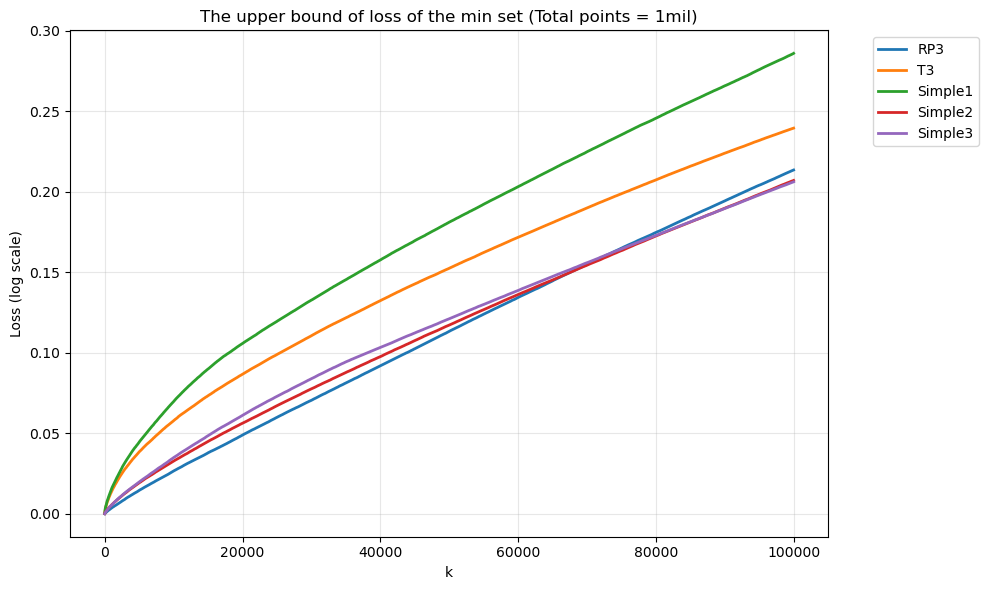

In [167]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_without_random.png')
plt.show()

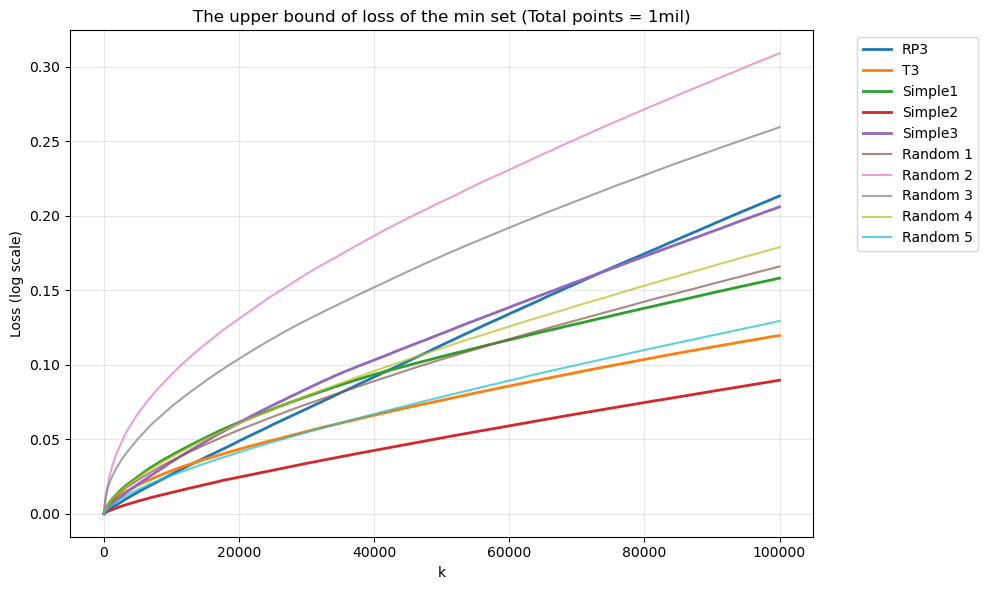

In [176]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Plot random losses
for i in range(5):
    plt.plot(x, loss_random[i], label=f'Random {i+1}', alpha=0.7)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(find_satisfying_points, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_with_random.png')
plt.show()

In [21]:
equations = combine_to_complex_equations(labels, coeffs_T3)

# Print the equations
for i, eq in enumerate(equations):
    print(f"Equation {i+1}:")
    print(eq)
    print()

Equation 1:
0.707107*z0*z0bar -0.707107*z1*z1bar = 0

Equation 2:
0.707107*z1*z1bar -0.707107*z2*z2bar = 0

Equation 3:
0.707107*z2*z2bar -0.707107*z3*z3bar = 0



In [23]:
coeffs_T3 @ coeffs_T3.T

Array([[ 0.99999994, -0.49999997,  0.        ],
       [-0.49999997,  0.99999994, -0.49999997],
       [ 0.        , -0.49999997,  0.99999994]], dtype=float32)

In [24]:
jnp.linalg.det(coeffs_T3 @ coeffs_T3.T)

Array(0.4999999, dtype=float32)

In [ ]:
# Double check this loss!!

In [13]:
compute_linear_independence_penalty(coeffs_T3)

Array(0.69314694, dtype=float32)

In [28]:
-jnp.log10(1/2)

Array(0.30102998, dtype=float32)

In [18]:

#gradient1 = grad_loss(coeffs_T3, basis_25mil, k=3000, lambda_reg=0)
print('Loss: ', loss_function(coeffs_T3, basis_25mil, k=3000, lambda_reg=0.1))
#print('Gradient: ', np.linalg.norm(np.reshape(gradient1, -1)))
#print(gradient1)

Loss:  0.12185765


In [20]:
loss_list_RP3 = []
loss_list_T3 = []
loss_list_ce = []

for num_selection in [10000, 50000, 100000, 300000, 500000, 1000000, 3000000, 5000000]:
    # Create a random key for JAX's pseudo-random number generator
    print(f"Number of points: {num_selection}")
    key = jax.random.PRNGKey(0)

    # Get the total number of points in the basis array
    num_total_points = basis_25mil.shape[0]

    # Generate random indices to select from the 'basis' array
    # We use replace=False to ensure the selected points are unique
    random_indices = jax.random.choice(key, num_total_points, shape=(num_selection,), replace=False)

    # Select the points from the 'basis' array using the random indices
    selected_basis = basis_25mil[random_indices]

    loss_list_RP3.append(loss_function(coeffs_RP3, selected_basis, k=3000, lambda_reg=0))
    loss_list_T3.append(loss_function(coeffs_T3, selected_basis, k=3000, lambda_reg=0))
    loss_list_ce.append(loss_function(coeffs_ce, selected_basis, k=3000, lambda_reg=0))

Number of points: 10000
Number of points: 50000
Number of points: 100000
Number of points: 300000
Number of points: 500000
Number of points: 1000000
Number of points: 3000000
Number of points: 5000000


In [4]:
len(basis_25mil)

5000457

### Check the loss scaling with the number of points

We should scale the lambda factor of the linear dependence loss according this

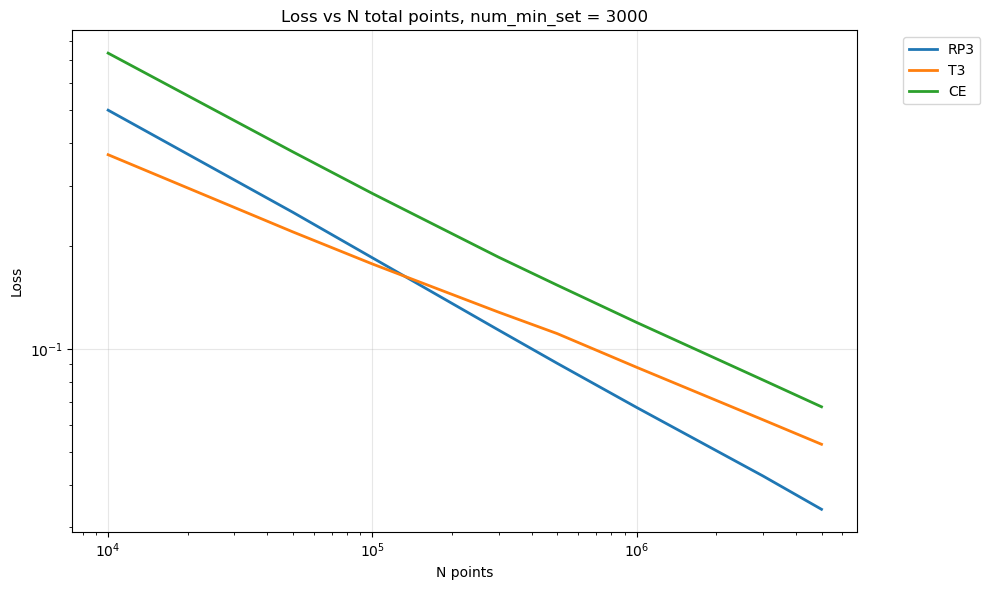

In [21]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = [10000, 50000, 100000, 300000, 500000, 1000000, 3000000, 5000000] 

# Plot RP3 loss
plt.plot(x, loss_list_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_list_T3, label='T3', linewidth=2)
plt.plot(x, loss_list_ce, label='CE', linewidth=2)

# Add labels and title
plt.xlabel('N points')
plt.ylabel('Loss')
plt.xscale('log')
plt.yscale('log')
plt.title('Loss vs N total points, num_min_set = 3000')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(find_satisfying_points, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
#plt.savefig('upper_bound_1mil_with_random.png')
plt.show()

In [44]:
loss_list_RP3

[Array(0.5001108, dtype=float32),
 Array(0.25115836, dtype=float32),
 Array(0.18474792, dtype=float32),
 Array(0.11351684, dtype=float32),
 Array(0.09071525, dtype=float32),
 Array(0.06732757, dtype=float32),
 Array(0.04244641, dtype=float32),
 Array(0.03388813, dtype=float32)]

In [45]:
loss_list_T3

[Array(0.37036142, dtype=float32),
 Array(0.22005497, dtype=float32),
 Array(0.17723687, dtype=float32),
 Array(0.12808976, dtype=float32),
 Array(0.11083718, dtype=float32),
 Array(0.08827558, dtype=float32),
 Array(0.06199992, dtype=float32),
 Array(0.05254296, dtype=float32)]

In [46]:
np.log10(loss_list_RP3)

array([-0.30093375, -0.60005236, -0.73342043, -0.94493973, -1.0423197 ,
       -1.171807  , -1.372159  , -1.4699523 ], dtype=float32)

In [47]:
(np.log10(loss_list_RP3)[-1] - np.log10(loss_list_RP3)[0]) / (np.log10(5000000) - np.log10(10000))

-0.4331350938821076

In [48]:
(np.log10(loss_list_T3)[-1] - np.log10(loss_list_T3)[0]) / (np.log10(5000000) - np.log10(10000))

-0.31423513817902426

In [33]:
0.06732*1000**(-0.4331350938821076)

0.0033786159319595297

Number of points: 10000
Number of points: 50000
Number of points: 100000
Number of points: 300000
Number of points: 500000
Number of points: 1000000
Number of points: 3000000
Number of points: 5000000


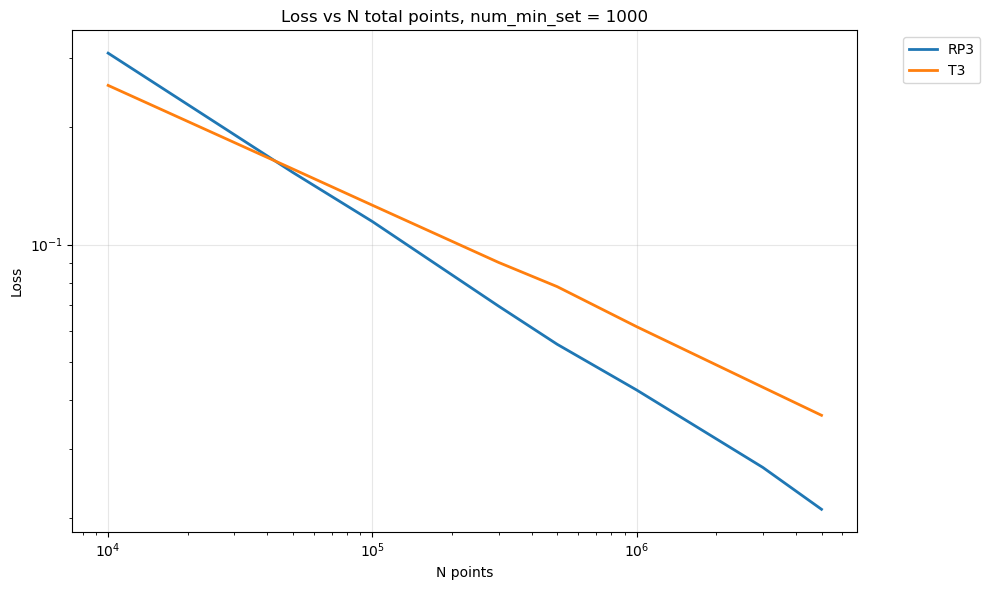

In [40]:
loss_list_RP3 = []
loss_list_T3 = []

for num_selection in [10000, 50000, 100000, 300000, 500000, 1000000, 3000000, 5000000]:
    # Create a random key for JAX's pseudo-random number generator
    print(f"Number of points: {num_selection}")
    key = jax.random.PRNGKey(0)

    # Get the total number of points in the basis array
    num_total_points = basis_25mil.shape[0]

    # Generate random indices to select from the 'basis' array
    # We use replace=False to ensure the selected points are unique
    random_indices = jax.random.choice(key, num_total_points, shape=(num_selection,), replace=False)

    # Select the points from the 'basis' array using the random indices
    selected_basis = basis_25mil[random_indices]

    loss_list_RP3.append(loss_function(coeffs_RP3, selected_basis, k=1000, lambda_reg=0))
    loss_list_T3.append(loss_function(coeffs_T3, selected_basis, k=1000, lambda_reg=0))
    
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = [10000, 50000, 100000, 300000, 500000, 1000000, 3000000, 5000000] 

# Plot RP3 loss
plt.plot(x, loss_list_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_list_T3, label='T3', linewidth=2)

# Add labels and title
plt.xlabel('N points')
plt.ylabel('Loss')
plt.xscale('log')
plt.yscale('log')
plt.title('Loss vs N total points, num_min_set = 1000')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(find_satisfying_points, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
#plt.savefig('upper_bound_1mil_with_random.png')
plt.show()

In [41]:
(np.log10(loss_list_RP3)[-1] - np.log10(loss_list_RP3)[0]) / (np.log10(5000000) - np.log10(10000))

-0.432752551039786

In [55]:
key = jax.random.PRNGKey(43)
loss_intersection_random = []
loss_linear_independence_random = []
for i in range(10000):
    key, subkey = jax.random.split(key)
    
    coeffs_random = jax.random.uniform(subkey, (3, 25), minval=-1, maxval=1)
    coeffs_random = normalize_coeffs(coeffs_random)
    loss_intersection_random.append(loss_function(coeffs_random, basis_25mil, k=3000, lambda_reg=0))
    loss_linear_independence_random.append(compute_linear_independence_penalty(coeffs_random))  

In [64]:
lossT3 = loss_function(coeffs_T3, basis_25mil, k=3000, lambda_reg=0)
lossRP3 = loss_function(coeffs_RP3, basis_25mil, k=3000, lambda_reg=0)

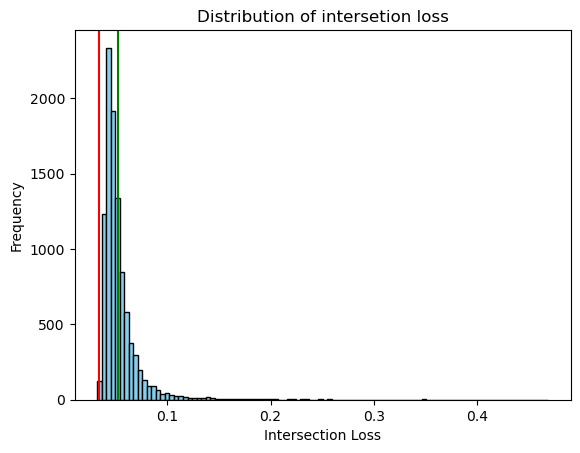

In [71]:
plt.hist(loss_intersection_random, bins=100, color='skyblue', edgecolor='black')
plt.axvline(x=lossRP3, color='red', linestyle='-')
plt.axvline(x=lossT3, color='green', linestyle='-')
# Add labels and a title
plt.xlabel('Intersection Loss')
plt.ylabel('Frequency')
plt.title('Distribution of intersetion loss')

# Display the plot
plt.show()

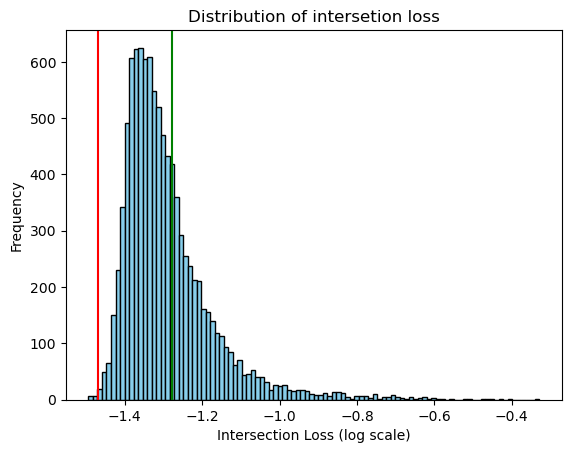

In [72]:
plt.hist(np.log10(loss_intersection_random), bins=100, color='skyblue', edgecolor='black')
plt.axvline(x=np.log10(lossRP3), color='red', linestyle='-')
plt.axvline(x=np.log10(lossT3), color='green', linestyle='-')
# Add labels and a title
plt.xlabel('Intersection Loss (log scale)')
plt.ylabel('Frequency')
plt.title('Distribution of intersetion loss')

# Display the plot
plt.show()

In [73]:
loss_linear_independence_RP3 = compute_linear_independence_penalty(coeffs_RP3)
loss_linear_independence_T3 = compute_linear_independence_penalty(coeffs_T3)  

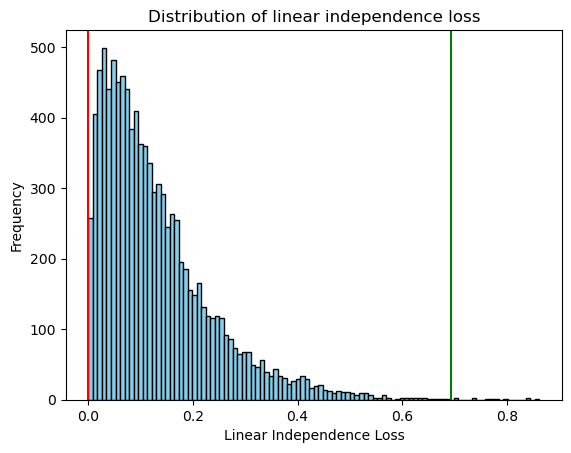

In [74]:
plt.hist(loss_linear_independence_random, bins=100, color='skyblue', edgecolor='black')
plt.axvline(x=loss_linear_independence_RP3, color='red', linestyle='-')
plt.axvline(x=loss_linear_independence_T3, color='green', linestyle='-')

# Add labels and a title
plt.xlabel('Linear Independence Loss')
plt.ylabel('Frequency')
plt.title('Distribution of linear independence loss')

# Display the plot
plt.show()

In [76]:
with open('/home/spencer/Documents/SLagSearch/data/loss_intersection_random_10k_25mil_3000.pkl', 'wb') as f:
    pickle.dump(loss_intersection_random, f)

with open('/home/spencer/Documents/SLagSearch/data/loss_linear_independence_random_10k_25mil_3000.pkl', 'wb') as f:
    pickle.dump(loss_linear_independence_random, f)

In [28]:
# Main execution
if __name__ == "__main__":
 
    # points = jnp.array(np.load("fermat_quintic_points.npy"))

    
    # Optimize equations
    print("\nOptimizing equations...")
    coeffs_from_ce, losses_from_ce = optimize_equations(
        pts_25mil_patch0, 
        init_coeffs=None,
        learning_rate=0.001, 
        num_steps=1000,
        num_min_set=3000,
        lambda_reg=0.1
    )
    
    # Analyze solution
   # analyze_solution(coeffs, points)
    
    # Save results
    #np.save("optimized_coefficients.npy", np.array(coeffs))
    #print("\nCoefficients saved to 'optimized_coefficients.npy'")


Optimizing equations...
Step 0, Loss: 15.966496, Independence Loss: 0.004415
Equation 1:
-0.090349*z0*z0bar + (0.133917+0.003325i)*z0*z1bar + (0.169865-0.054883i)*z0*z2bar + (0.126995-0.034742i)*z0*z3bar + (-0.006614-0.018040i)*z0*z4bar + (0.133917-0.003325i)*z1*z0bar + 0.213736*z1*z1bar + (0.065482+0.014573i)*z1*z2bar + (0.025737-0.025486i)*z1*z3bar + (-0.170185+0.169288i)*z1*z4bar + (0.169865+0.054883i)*z2*z0bar + (0.065482-0.014573i)*z2*z1bar + 0.179568*z2*z2bar + (-0.028379-0.088806i)*z2*z3bar + (-0.138565-0.061260i)*z2*z4bar + (0.126995+0.034742i)*z3*z0bar + (0.025737+0.025486i)*z3*z1bar + (-0.028379+0.088806i)*z3*z2bar -0.455605*z3*z3bar + (0.041857-0.106936i)*z3*z4bar + (-0.006614+0.018040i)*z4*z0bar + (-0.170185-0.169288i)*z4*z1bar + (-0.138565+0.061260i)*z4*z2bar + (0.041857+0.106936i)*z4*z3bar -0.056658*z4*z4bar = 0

Equation 2:
-0.097851*z0*z0bar + (0.064001-0.170959i)*z0*z1bar + (0.032055+0.196296i)*z0*z2bar + (-0.078372+0.075238i)*z0*z3bar + (-0.124232-0.038082i)*z0*z4bar

Step 40, Loss: 13.106239, Independence Loss: 0.004363
Equation 1:
-0.093244*z0*z0bar + (0.134353+0.004091i)*z0*z1bar + (0.169939-0.054061i)*z0*z2bar + (0.125472-0.035320i)*z0*z3bar + (-0.007420-0.017726i)*z0*z4bar + (0.134353-0.004091i)*z1*z0bar + 0.211973*z1*z1bar + (0.065309+0.014153i)*z1*z2bar + (0.026778-0.025622i)*z1*z3bar + (-0.170249+0.168402i)*z1*z4bar + (0.169939+0.054061i)*z2*z0bar + (0.065309-0.014153i)*z2*z1bar + 0.180283*z2*z2bar + (-0.027844-0.089066i)*z2*z3bar + (-0.138972-0.061706i)*z2*z4bar + (0.125472+0.035320i)*z3*z0bar + (0.026778+0.025622i)*z3*z1bar + (-0.027844+0.089066i)*z3*z2bar -0.458192*z3*z3bar + (0.041645-0.105741i)*z3*z4bar + (-0.007420+0.017726i)*z4*z0bar + (-0.170249-0.168402i)*z4*z1bar + (-0.138972+0.061706i)*z4*z2bar + (0.041645+0.105741i)*z4*z3bar -0.057483*z4*z4bar = 0

Equation 2:
-0.090278*z0*z0bar + (0.063907-0.172353i)*z0*z1bar + (0.034450+0.196535i)*z0*z2bar + (-0.075851+0.077838i)*z0*z3bar + (-0.122883-0.039237i)*z0*z4bar + (0.063907+0.172353i)*

Step 80, Loss: 9.409540, Independence Loss: 0.004328
Equation 1:
-0.094895*z0*z0bar + (0.134801+0.004599i)*z0*z1bar + (0.170077-0.053650i)*z0*z2bar + (0.124570-0.035892i)*z0*z3bar + (-0.007803-0.017315i)*z0*z4bar + (0.134801-0.004599i)*z1*z0bar + 0.210592*z1*z1bar + (0.065173+0.013790i)*z1*z2bar + (0.027442-0.025589i)*z1*z3bar + (-0.170302+0.167783i)*z1*z4bar + (0.170077+0.053650i)*z2*z0bar + (0.065173-0.013790i)*z2*z1bar + 0.180584*z2*z2bar + (-0.027501-0.089222i)*z2*z3bar + (-0.139181-0.061915i)*z2*z4bar + (0.124570+0.035892i)*z3*z0bar + (0.027442+0.025589i)*z3*z1bar + (-0.027501+0.089222i)*z3*z2bar -0.459538*z3*z3bar + (0.041826-0.105016i)*z3*z4bar + (-0.007803+0.017315i)*z4*z0bar + (-0.170302-0.167783i)*z4*z1bar + (-0.139181+0.061915i)*z4*z2bar + (0.041826+0.105016i)*z4*z3bar -0.058420*z4*z4bar = 0

Equation 2:
-0.079650*z0*z0bar + (0.062839-0.173058i)*z0*z1bar + (0.036726+0.196539i)*z0*z2bar + (-0.072297+0.079994i)*z0*z3bar + (-0.123119-0.042678i)*z0*z4bar + (0.062839+0.173058i)*z

Step 120, Loss: 6.284069, Independence Loss: 0.004279
Equation 1:
-0.096034*z0*z0bar + (0.135133+0.004803i)*z0*z1bar + (0.170117-0.053435i)*z0*z2bar + (0.123971-0.036125i)*z0*z3bar + (-0.007830-0.016973i)*z0*z4bar + (0.135133-0.004803i)*z1*z0bar + 0.209781*z1*z1bar + (0.065133+0.013626i)*z1*z2bar + (0.027829-0.025552i)*z1*z3bar + (-0.170368+0.167382i)*z1*z4bar + (0.170117+0.053435i)*z2*z0bar + (0.065133-0.013626i)*z2*z1bar + 0.180739*z2*z2bar + (-0.027308-0.089279i)*z2*z3bar + (-0.139274-0.062002i)*z2*z4bar + (0.123971+0.036125i)*z3*z0bar + (0.027829+0.025552i)*z3*z1bar + (-0.027308+0.089279i)*z3*z2bar -0.460381*z3*z3bar + (0.042073-0.104586i)*z3*z4bar + (-0.007830+0.016973i)*z4*z0bar + (-0.170368-0.167382i)*z4*z1bar + (-0.139274+0.062002i)*z4*z2bar + (0.042073+0.104586i)*z4*z3bar -0.059079*z4*z4bar = 0

Equation 2:
-0.068755*z0*z0bar + (0.061271-0.173282i)*z0*z1bar + (0.038695+0.196398i)*z0*z2bar + (-0.068617+0.081470i)*z0*z3bar + (-0.124061-0.046809i)*z0*z4bar + (0.061271+0.173282i)*

Step 160, Loss: 4.490675, Independence Loss: 0.004196
Equation 1:
-0.096919*z0*z0bar + (0.135368+0.004923i)*z0*z1bar + (0.170125-0.053290i)*z0*z2bar + (0.123513-0.036190i)*z0*z3bar + (-0.007795-0.016747i)*z0*z4bar + (0.135368-0.004923i)*z1*z0bar + 0.209230*z1*z1bar + (0.065109+0.013532i)*z1*z2bar + (0.028099-0.025561i)*z1*z3bar + (-0.170420+0.167099i)*z1*z4bar + (0.170125+0.053290i)*z2*z0bar + (0.065109-0.013532i)*z2*z1bar + 0.180855*z2*z2bar + (-0.027184-0.089294i)*z2*z3bar + (-0.139323-0.062068i)*z2*z4bar + (0.123513+0.036190i)*z3*z0bar + (0.028099+0.025561i)*z3*z1bar + (-0.027184+0.089294i)*z3*z2bar -0.461049*z3*z3bar + (0.042254-0.104287i)*z3*z4bar + (-0.007795+0.016747i)*z4*z0bar + (-0.170420-0.167099i)*z4*z1bar + (-0.139323+0.062068i)*z4*z2bar + (0.042254+0.104287i)*z4*z3bar -0.059478*z4*z4bar = 0

Equation 2:
-0.058185*z0*z0bar + (0.059699-0.173238i)*z0*z1bar + (0.040495+0.196221i)*z0*z2bar + (-0.065042+0.082506i)*z0*z3bar + (-0.125127-0.050849i)*z0*z4bar + (0.059699+0.173238i)*

...

Step 800, Loss: 0.997309, Independence Loss: 0.001306
Equation 1:
-0.146379*z0*z0bar + (0.137646-0.000436i)*z0*z1bar + (0.168036-0.058845i)*z0*z2bar + (0.118459-0.025638i)*z0*z3bar + (-0.012664-0.007428i)*z0*z4bar + (0.137646+0.000436i)*z1*z0bar + 0.194688*z1*z1bar + (0.063576+0.015667i)*z1*z2bar + (0.032048-0.025647i)*z1*z3bar + (-0.166117+0.160584i)*z1*z4bar + (0.168036+0.058845i)*z2*z0bar + (0.063576-0.015667i)*z2*z1bar + 0.181448*z2*z2bar + (-0.032339-0.082593i)*z2*z3bar + (-0.132250-0.057851i)*z2*z4bar + (0.118459+0.025638i)*z3*z0bar + (0.032048+0.025647i)*z3*z1bar + (-0.032339+0.082593i)*z3*z2bar -0.490827*z3*z3bar + (0.047536-0.094332i)*z3*z4bar + (-0.012664+0.007428i)*z4*z0bar + (-0.166117-0.160584i)*z4*z1bar + (-0.132250+0.057851i)*z4*z2bar + (0.047536+0.094332i)*z4*z3bar -0.088209*z4*z4bar = 0

Equation 2:
0.098674*z0*z0bar + (0.049291-0.162422i)*z0*z1bar + (0.063727+0.183283i)*z0*z2bar + (-0.054090+0.076713i)*z0*z3bar + (-0.123259-0.075020i)*z0*z4bar + (0.049291+0.162422i)*z

Step 840, Loss: 0.973824, Independence Loss: 0.001300
Equation 1:
-0.149970*z0*z0bar + (0.137791-0.000839i)*z0*z1bar + (0.167880-0.059299i)*z0*z2bar + (0.118036-0.024835i)*z0*z3bar + (-0.012955-0.006786i)*z0*z4bar + (0.137791+0.000839i)*z1*z0bar + 0.193172*z1*z1bar + (0.063384+0.015773i)*z1*z2bar + (0.032242-0.025653i)*z1*z3bar + (-0.165794+0.160168i)*z1*z4bar + (0.167880+0.059299i)*z2*z0bar + (0.063384-0.015773i)*z2*z1bar + 0.181728*z2*z2bar + (-0.032633-0.082206i)*z2*z3bar + (-0.131822-0.057586i)*z2*z4bar + (0.118036+0.024835i)*z3*z0bar + (0.032242+0.025653i)*z3*z1bar + (-0.032633+0.082206i)*z3*z2bar -0.492365*z3*z3bar + (0.047803-0.093858i)*z3*z4bar + (-0.012955+0.006786i)*z4*z0bar + (-0.165794-0.160168i)*z4*z1bar + (-0.131822+0.057586i)*z4*z2bar + (0.047803+0.093858i)*z4*z3bar -0.089993*z4*z4bar = 0

Equation 2:
0.106287*z0*z0bar + (0.048995-0.161931i)*z0*z1bar + (0.064286+0.182591i)*z0*z2bar + (-0.053912+0.076155i)*z0*z3bar + (-0.122939-0.075600i)*z0*z4bar + (0.048995+0.161931i)*z

Step 880, Loss: 0.954383, Independence Loss: 0.001316
Equation 1:
-0.153399*z0*z0bar + (0.137919-0.001198i)*z0*z1bar + (0.167737-0.059707i)*z0*z2bar + (0.117615-0.024111i)*z0*z3bar + (-0.013225-0.006175i)*z0*z4bar + (0.137919+0.001198i)*z1*z0bar + 0.191758*z1*z1bar + (0.063194+0.015860i)*z1*z2bar + (0.032404-0.025657i)*z1*z3bar + (-0.165488+0.159785i)*z1*z4bar + (0.167737+0.059707i)*z2*z0bar + (0.063194-0.015860i)*z2*z1bar + 0.181924*z2*z2bar + (-0.032899-0.081861i)*z2*z3bar + (-0.131422-0.057340i)*z2*z4bar + (0.117615+0.024111i)*z3*z0bar + (0.032404+0.025657i)*z3*z1bar + (-0.032899+0.081861i)*z3*z2bar -0.493761*z3*z3bar + (0.048044-0.093430i)*z3*z4bar + (-0.013225+0.006175i)*z4*z0bar + (-0.165488-0.159785i)*z4*z1bar + (-0.131422+0.057340i)*z4*z2bar + (0.048044+0.093430i)*z4*z3bar -0.091679*z4*z4bar = 0

Equation 2:
0.113421*z0*z0bar + (0.048747-0.161494i)*z0*z1bar + (0.064766+0.181953i)*z0*z2bar + (-0.053729+0.075626i)*z0*z3bar + (-0.122646-0.076128i)*z0*z4bar + (0.048747+0.161494i)*z

Step 920, Loss: 0.938310, Independence Loss: 0.001348
Equation 1:
-0.156624*z0*z0bar + (0.138035-0.001514i)*z0*z1bar + (0.167618-0.060073i)*z0*z2bar + (0.117193-0.023457i)*z0*z3bar + (-0.013458-0.005616i)*z0*z4bar + (0.138035+0.001514i)*z1*z0bar + 0.190454*z1*z1bar + (0.063014+0.015934i)*z1*z2bar + (0.032535-0.025657i)*z1*z3bar + (-0.165203+0.159433i)*z1*z4bar + (0.167618+0.060073i)*z2*z0bar + (0.063014-0.015934i)*z2*z1bar + 0.182077*z2*z2bar + (-0.033144-0.081554i)*z2*z3bar + (-0.131050-0.057118i)*z2*z4bar + (0.117193+0.023457i)*z3*z0bar + (0.032535+0.025657i)*z3*z1bar + (-0.033144+0.081554i)*z3*z2bar -0.495007*z3*z3bar + (0.048258-0.093045i)*z3*z4bar + (-0.013458+0.005616i)*z4*z0bar + (-0.165203-0.159433i)*z4*z1bar + (-0.131050+0.057118i)*z4*z2bar + (0.048258+0.093045i)*z4*z3bar -0.093274*z4*z4bar = 0

Equation 2:
0.120145*z0*z0bar + (0.048547-0.161119i)*z0*z1bar + (0.065196+0.181329i)*z0*z2bar + (-0.053531+0.075129i)*z0*z3bar + (-0.122432-0.076577i)*z0*z4bar + (0.048547+0.161119i)*z

Step 960, Loss: 0.924981, Independence Loss: 0.001395
Equation 1:
-0.159769*z0*z0bar + (0.138147-0.001789i)*z0*z1bar + (0.167506-0.060388i)*z0*z2bar + (0.116783-0.022876i)*z0*z3bar + (-0.013660-0.005122i)*z0*z4bar + (0.138147+0.001789i)*z1*z0bar + 0.189248*z1*z1bar + (0.062841+0.015992i)*z1*z2bar + (0.032641-0.025654i)*z1*z3bar + (-0.164933+0.159113i)*z1*z4bar + (0.167506+0.060388i)*z2*z0bar + (0.062841-0.015992i)*z2*z1bar + 0.182124*z2*z2bar + (-0.033360-0.081278i)*z2*z3bar + (-0.130700-0.056919i)*z2*z4bar + (0.116783+0.022876i)*z3*z0bar + (0.032641+0.025654i)*z3*z1bar + (-0.033360+0.081278i)*z3*z2bar -0.496116*z3*z3bar + (0.048442-0.092692i)*z3*z4bar + (-0.013660+0.005122i)*z4*z0bar + (-0.164933-0.159113i)*z4*z1bar + (-0.130700+0.056919i)*z4*z2bar + (0.048442+0.092692i)*z4*z3bar -0.094842*z4*z4bar = 0

Equation 2:
0.126518*z0*z0bar + (0.048384-0.160786i)*z0*z1bar + (0.065565+0.180748i)*z0*z2bar + (-0.053310+0.074674i)*z0*z3bar + (-0.122300-0.076953i)*z0*z4bar + (0.048384+0.160786i)*z